In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import os
import pandas as pd
from pathlib import Path
from scipy import stats
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid", font_scale=1.1)

# Load Data

In [3]:
# CPI: https://www.minneapolisfed.org/about-us/monetary-policy/inflation-calculator/consumer-price-index-1913-
cpi_map = {
    2013: 233,
    2014: 236.7,
    2015: 237,
    2016: 240,
    2017: 245.1,
    2018: 251.1,
    2019: 255.7,
    2020: 258.8,
    2021: 271,
    2022: 292.7,
    2023: 304.7,
    2024: 313.7,
    2025: 322.3
}

In [4]:
final_spine_codes = [
    22551, 22552, 22548, 63081, 63082, 22554, 22585, 22856, 22845, 22846, 22558, 22585, 22630, 22632, 22600, 22590, 22595, 22614, 
    22840, 22612, 22842, 22843, 63020, 63035, 63040, 63045, 63048, 63051, 63077, 23078, 23085, 63086, 63087, 63088, 63101, 63103,
    22556, 22585, 22851, 22845, 22846, 63046, 63048, 63055, 63057, 63064, 63066, 63085, 63086, 63087, 22610, 22840, 22842, 
    22843, 22844, 63090, 63091, 22558, 22585, 22857, 22862, 22845, 22846, 63030, 63047, 63035, 63042, 63044, 63048, 63012, 22630, 
    22632, 22612, 22614, 22633, 22634, 22840, 22842, 22843, 22853
]

In [5]:
cpt_spine_unmerged = {
    "instrumentation": ["22840", "22842", "22843", "22844", "22845", "22846", "22847", "22853", "22854", "22859", "22849"],
    "bone_grafting": ["20930", "20931", "20936", "20937", "20938", "20939"],
    "decompression_add_ons": ["63048", "63035"],
    "decompression_cervical": ["63001", "63015", "63045", "63020", "63040", "63043", "63050", "63051", "63075", "63076", "63081", "63082"],
    "decompression_thoracic": ["63003", "63016", "63046", "63085", "63086", "63087"],
    "decompression_lumbar": ["63005", "63017", "63047", "63030", "63042", "63044", "63052", "63053", "62380", "63090", "63091"],
    "fusion_add_ons": ["22585", "22614", "22534"],
    "fusion_multiple_regions": ["22800", "22802", "22804", "22810", "22812"],
    "fusion_cervical": ["22551", "22552", "22554", "22590", "22595"],
    "fusion_thoracic": ["22556", "22532"],
    "fusion_lumbar": ["22558", "22533", "22612", "22630", "22632", "22633", "22634"],
}


cpt_spine = {
    "instrumentation": ["22840", "22842", "22843", "22844", "22845", "22846", "22847", "22853", "22854", "22859", "22849"],
    "bone_grafting": ["20930", "20931", "20936", "20937", "20938", "20939"],
    "decompression": [
        "63001", "63015", "63045", "63020", "63040", "63043", "63048", "63035", 
        "63050", "63051", "63075", "63076", "63081", "63082", "63003", "63016",
        "63046", "63085", "63086", "63087", "63005", "63017", "63047", "63030",
        "63042", "63044", "63052", "63053", "62380", "63090", "63091", "63012",
        "63055", "63057", "63064", "63066", "63077", "63088", "63101", "63103"
    ],
    "fusion": [
        "22800", "22802", "22804", "22810", "22812", "22585", "22614", "22534", 
        "22551", "22552", "22554", "22590", "22595", "22556", "22532", "22558",
        "22533", "22612", "22630", "22632", "22633", "22634", "22548", "22600",
        "22610", "23078", "23085"
    ],
    # "arthroplasty": ["22856", "22857", "22862", "22851"],
    # "optic_chiasm_decompression": ["66214"]
}   

spine_addons = [
    "63016", "63017", "63035", "63043", "63044", "63046", "63048", "63051", "63053", 
    "63057", "63066", "63076", "63082", "63086", "63087", "63088", "63091", "63103",
    "22552", "22533", "22632", "22634", "22614"
]

cpt_neurovasc = {
    'aneurysm_coiling_embo': ['61624', '61626'],
    'transcath_therapy': ['75894', '75898'],
    'thrombectomy': ['61645'],
    'stent': ['37215', '37216', '37236'], # '37237'
    'intracranial_stent_angioplasty': ['61635', '61630', '61635', '61640', '61642'], # '61641'
    # 'intraarterial_pharm_infusion': ['61650', '61651'],
    # 'temp_balloon': ['61623'],
    # 'cerebral_angio': ['36221', '36222', '36223', '36224', '36225', '36226', '36227', '36228']
}

cpt_map = {}

for category, codes in cpt_spine.items():
    for code in codes:
        if code not in spine_addons:
            cpt_map[int(code)] = category

for category, codes in cpt_neurovasc.items():
    for code in codes:
        cpt_map[int(code)] = category

In [6]:
for procedure in cpt_spine:
    print(f"{procedure}: {', '.join(cpt_spine[procedure])}")
for procedure in cpt_neurovasc:
    print(f"{procedure}: {', '.join(cpt_neurovasc[procedure])}")

instrumentation: 22840, 22842, 22843, 22844, 22845, 22846, 22847, 22853, 22854, 22859, 22849
bone_grafting: 20930, 20931, 20936, 20937, 20938, 20939
decompression: 63001, 63015, 63045, 63020, 63040, 63043, 63048, 63035, 63050, 63051, 63075, 63076, 63081, 63082, 63003, 63016, 63046, 63085, 63086, 63087, 63005, 63017, 63047, 63030, 63042, 63044, 63052, 63053, 62380, 63090, 63091, 63012, 63055, 63057, 63064, 63066, 63077, 63088, 63101, 63103
fusion: 22800, 22802, 22804, 22810, 22812, 22585, 22614, 22534, 22551, 22552, 22554, 22590, 22595, 22556, 22532, 22558, 22533, 22612, 22630, 22632, 22633, 22634, 22548, 22600, 22610, 23078, 23085
aneurysm_coiling_embo: 61624, 61626
transcath_therapy: 75894, 75898
thrombectomy: 61645
stent: 37215, 37216, 37236
intracranial_stent_angioplasty: 61635, 61630, 61635, 61640, 61642


In [8]:
current_dir = os.getcwd()

In [9]:
spine_data = pd.read_csv(os.path.join(current_dir, "processed-data", "spine_cpt_processed_with_ortho.csv"))
neurovasc_data = pd.read_csv(os.path.join(current_dir, "processed-data", "neurovasc_cpt_processed.csv"))

# Analysis

In [11]:
for df in [spine_data, neurovasc_data]:
    df['CPI'] = df['year'].map(cpi_map).fillna(0)
    
    # Adjusted amounts
    df['Avg_Mdcr_Stdzd_Amt_adj'] = df['Avg_Mdcr_Stdzd_Amt'] / df['CPI'] * cpi_map[2023]
    df['Avg_Mdcr_Pymt_Amt_adj'] = df['Avg_Mdcr_Pymt_Amt'] / df['CPI'] * cpi_map[2023]

    # Raw amounts summed over services per provider
    df['Tot_Srvcs_Spend'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt'] 
    df['Tot_Pymt'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt'] 

    # Raw amounts summed over services per provider, adjusted
    df['Tot_Srvcs_Spend_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Stdzd_Amt_adj'] 
    df['Tot_Pymt_adj'] = df['Tot_Srvcs'] * df['Avg_Mdcr_Pymt_Amt_adj'] 

In [12]:
spine_data = spine_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt", "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]
neurovasc_data = neurovasc_data[["HCPCS_Cd", "Rndrng_NPI", "Tot_Srvcs", "Avg_Mdcr_Stdzd_Amt", "Avg_Mdcr_Pymt_Amt",  "Tot_Srvcs_Spend", "Tot_Pymt", "Avg_Mdcr_Stdzd_Amt_adj", "Avg_Mdcr_Pymt_Amt_adj", "Tot_Srvcs_Spend_adj", "Tot_Pymt_adj", "year"]]

In [13]:
for data in [spine_data, neurovasc_data]:
    data['procedure'] = data['HCPCS_Cd'].map(cpt_map)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_29671/2081504999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['procedure'] = data['HCPCS_Cd'].map(cpt_map)


In [14]:
groupby_key = 'procedure'
specialty_name = ["Spine", "Neurovasc"]

In [15]:
# Group by procedure and year, and summarize
util_2023_2013_adj_spine = (
    spine_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_neurovasc = (
    neurovasc_data
    .groupby([groupby_key, 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

In [16]:
# Group by procedure and year, and summarize
util_2023_2013_adj_spine_by_cpt = (
    spine_data
    .groupby(['HCPCS_Cd', 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
    )
)

util_2023_2013_adj_neurovasc_by_cpt = (
    neurovasc_data
    .groupby(['HCPCS_Cd', 'year'], as_index=False)
    .agg(
        Sum_Utilization=('Tot_Srvcs', 'sum'),
        Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
        Sum_Pymt=('Tot_Pymt', 'sum'),
        Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
        Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
        Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
        Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
        Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
        Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
)

## Utilization per Year

In [17]:
util_2023_2013_adj_spine['Sum_Utilization'].sum(), util_2023_2013_adj_neurovasc['Sum_Utilization'].sum()

(4386309.0, 98132.0)

In [40]:
4386309.0+98132.0

4484441.0

In [18]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr = (
        specialty.sort_values(['procedure', 'year'])
        .groupby('procedure')
        .apply(lambda g: g['Sum_Utilization'].pct_change().mean() * 100)
        .reset_index(name='AAGR_%')
    )

    # Get average utilization per procedure as weights
    weights = specialty.groupby('procedure')['Sum_Utilization'].mean()
    
    # Merge with AAGR result
    aagr_weighted = aagr.set_index('procedure').join(weights.rename('avg_util'))
    
    # Weighted average
    weighted_aagr = (aagr_weighted['AAGR_%'] * aagr_weighted['avg_util']).sum() / aagr_weighted['avg_util'].sum()
    
    aagrs[specialty_name[i]] = (aagr, weighted_aagr)

In [19]:
aagrs['Spine'][1], aagrs['Neurovasc'][1]

(4.793403124468733, 13.967804208287351)

In [20]:
aagrs['Spine'][0]

,procedure,AAGR_%
0,bone_grafting,-0.700399
1,decompression,-1.968604
2,fusion,0.109046
3,instrumentation,13.144164


In [21]:
aagrs['Neurovasc'][0]

,procedure,AAGR_%
0,aneurysm_coiling_embo,12.583117
1,intracranial_stent_angioplasty,12.722593
2,stent,20.511719
3,thrombectomy,25.479072
4,transcath_therapy,10.173063


In [22]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovasc'][0]['AAGR_%'])

Ttest_indResult(statistic=-3.0314786892710255, pvalue=0.01907476184328556)

In [74]:
cagrs = {}
for i, df in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    cagr_by_procedure = (
        df[df['year'].isin([2013, 2016, 2023])]
        .groupby(['procedure', 'year'])['Sum_Utilization']
        .sum()
        .unstack('year')
        .assign(CAGR_pct=lambda x: ((x[2023] / x[2013]) ** (1/10) - 1) * 100)
        .assign(CAGR_pct_alt=lambda x: ((x[2023] / x[2016]) ** (1/10) - 1) * 100)
        .reset_index()
        .rename(columns={2013: 'util_2013', 2016: 'util_2013', 2023: 'util_2023'})
    )

    cagrs[specialty_name[i]] = cagr_by_procedure

In [61]:
colors = [
    "tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", 
    "tab:pink", "tab:gray", "tab:olive", "tab:cyan", "black", "gold" 
]

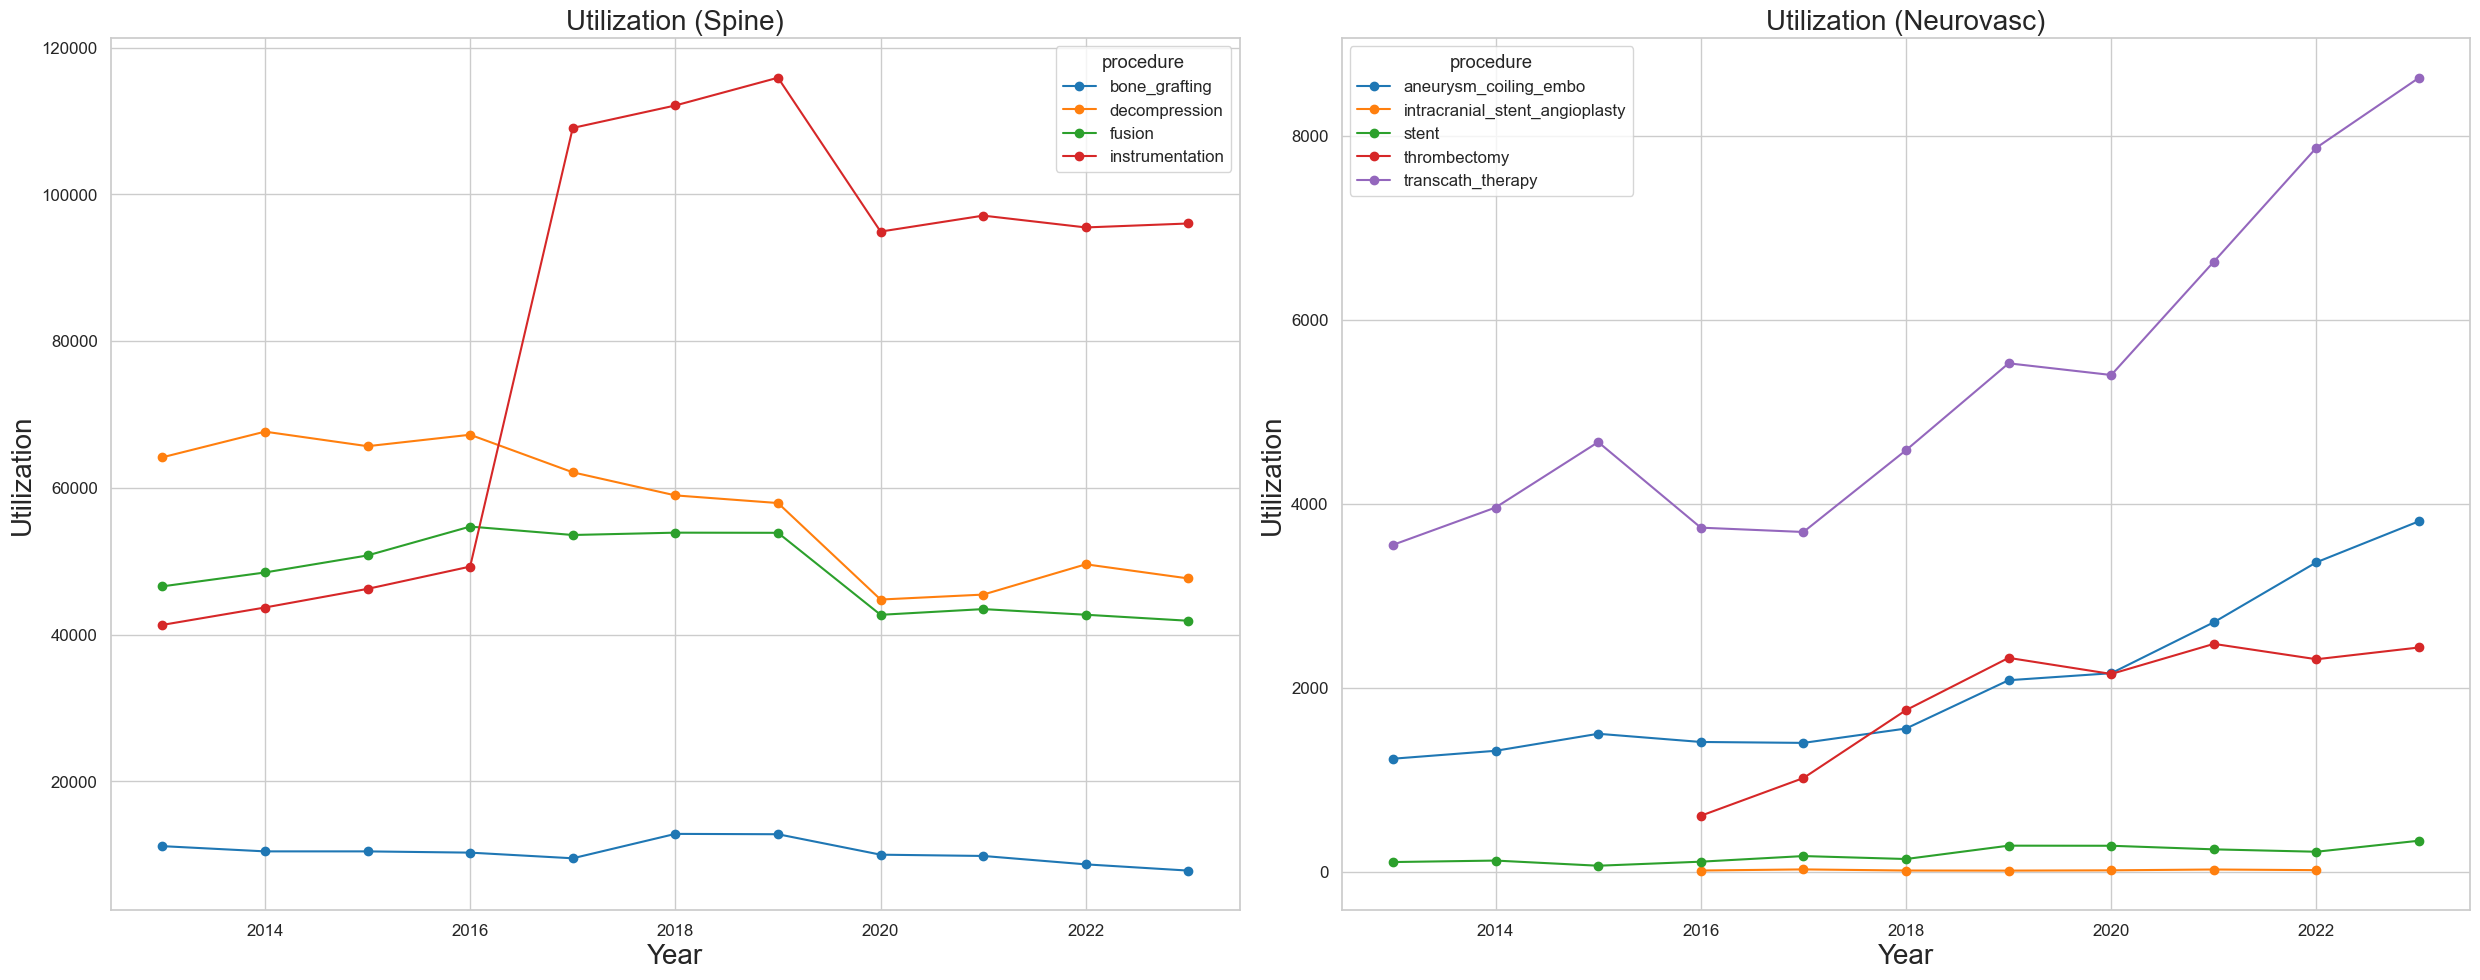

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')

        x = df_sorted['year']
        y = df_sorted['Sum_Utilization']

        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Utilization", fontsize=20)
    axs[i].set_title(f"Utilization ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

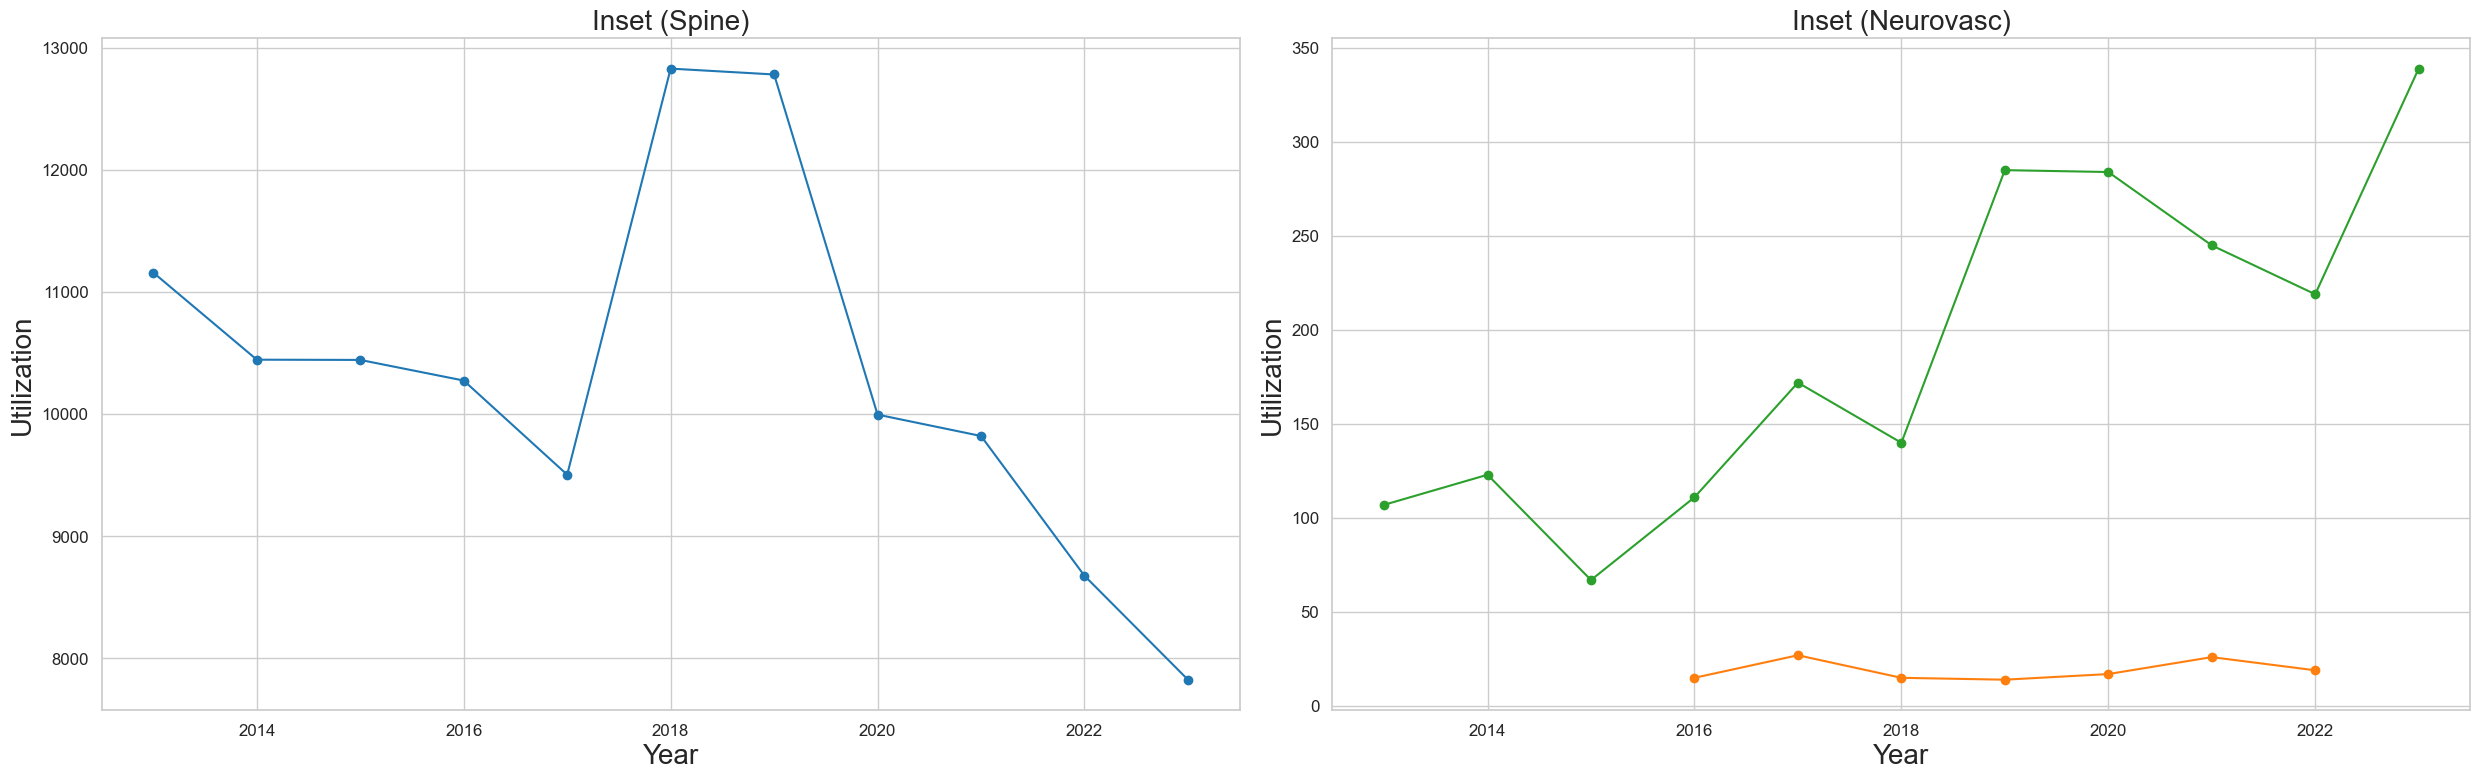

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 
plot_inset = [
    ['fusion_cervical', 'bone_grafting', 'decompression_cervical', 'decompression_thoracic', 'fusion_thoracic', 'fusion_multiple_regions'],
    ["intracranial_stent_angioplasty", "stent", "intraarterial_pharm_infusion", "temp_balloon"]
]

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')

        x = df_sorted['year']
        y = df_sorted['Sum_Utilization']

        if label in plot_inset[i]:
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])

        p_num += 1
    
    # axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Utilization", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [219]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 
# for i, specialty in enumerate([util_2023_2013_adj_spine_by_cpt, util_2023_2013_adj_neurovasc_by_cpt]):
#     grouped = specialty.groupby('HCPCS_Cd')
#     p_num = 0
    
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')

#         x = df_sorted['year']
#         y = df_sorted['Sum_Utilization']

#         axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-')
#         p_num += 1
    
#     axs[i].legend(title=groupby_key)
#     axs[i].set_xlabel("Year")
#     axs[i].set_ylabel("Utilization")
#     axs[i].set_title(f"Utilization ({specialty_name[i]})")

# plt.tight_layout()

In [220]:
# def add_inset(ax, rel=[0.6, 0.55, 0.35, 0.35]):
#     """
#     Create an inset inside `ax` without mpl_toolkits.
#     rel = [left, bottom, width, height] in *axes-relative* coords (0..1).
#     """
#     fig = ax.figure
#     bbox = ax.get_position()  # in figure coords
#     left   = bbox.x0 + rel[0] * bbox.width
#     bottom = bbox.y0 + rel[1] * bbox.height
#     width  = rel[2] * bbox.width
#     height = rel[3] * bbox.height
#     return fig.add_axes([left, bottom, width, height])

In [221]:
# # with inset
# fig, axs = plt.subplots(1, 2, figsize=(25, 15)) 

# plot_inset = [
#     ['fusion_cervical', 'bone_grafting', 'decompression_cervical', 'decompression_thoracic', 'fusion_thoracic', 'fusion_multiple_regions'],
#     ["intracranial_stent_angioplasty", "intraarterial_pharm_infusion", "temp_balloon"]
# ]

# inset_location = [[0.0, -0.05, 0.6, 0.3], [0.0, 0.8, 0.55, 0.3]]

# for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
#     grouped = specialty.groupby(groupby_key)
#     axins = add_inset(axs[i], rel=inset_location[i])
#     max_val = 0

#     procedure_num = 0
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')

#         x = df_sorted['year']
#         y = df_sorted['Sum_Utilization']

#         max_val = max(max_val, max(y))

#         if label in plot_inset[i]:
#             axins.plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[procedure_num])
#         else:
#             axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[procedure_num])

#         procedure_num += 1

#     # collect handles + labels from both axes
#     handles_main, labels_main = axs[i].get_legend_handles_labels()
#     handles_inset, labels_inset = axins.get_legend_handles_labels()
    
#     # merge them
#     all_handles = handles_main + handles_inset
#     all_labels  = labels_main + labels_inset
    
#     axs[i].legend(all_handles, all_labels, loc="upper right")

#     axs[i].set_xlabel("Year")
#     axs[i].set_ylabel("Utilization")
#     axs[i].set_ylim([-100, max_val + 100])
#     axs[i].set_title(f"Utilization ({specialty_name[i]})")

# plt.tight_layout()

## Average Standardized Payment

In [23]:
util_2023_2013_adj_spine['CI_lower_avg_price_per_service'] = util_2023_2013_adj_spine['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_spine['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_spine['CI_upper_avg_price_per_service'] = util_2023_2013_adj_spine['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_spine['Avg_Price_per_service_adj_sem']

util_2023_2013_adj_neurovasc['CI_lower_avg_price_per_service'] = util_2023_2013_adj_neurovasc['Avg_Price_per_service_adj'] - 1.96 * util_2023_2013_adj_neurovasc['Avg_Price_per_service_adj_sem']
util_2023_2013_adj_neurovasc['CI_upper_avg_price_per_service'] = util_2023_2013_adj_neurovasc['Avg_Price_per_service_adj'] + 1.96 * util_2023_2013_adj_neurovasc['Avg_Price_per_service_adj_sem']

In [24]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr = (
        specialty.sort_values(['procedure', 'year'])
        .groupby('procedure')
        .apply(lambda g: g['Avg_Price_per_service_adj'].interpolate().pct_change().mean() * 100)
        .reset_index(name='AAGR_%')
    )

    # Get average utilization per procedure as weights
    weights = specialty.groupby('procedure')['Avg_Price_per_service_adj'].mean()
    
    # Merge with AAGR result
    aagr_weighted = aagr.set_index('procedure').join(weights.rename('avg_price_per_service'))
    
    # Weighted average
    weighted_aagr = (aagr_weighted['AAGR_%'] * aagr_weighted['avg_price_per_service']).sum() / aagr_weighted['avg_price_per_service'].sum()
    
    aagrs[specialty_name[i]] = (aagr, weighted_aagr)

In [25]:
aagrs['Spine'][1], aagrs['Neurovasc'][1]

(-3.8667783197745957, -3.212155207231404)

In [26]:
aagrs['Spine'][0]

,procedure,AAGR_%
0,bone_grafting,-4.781295
1,decompression,-4.023834
2,fusion,-3.061018
3,instrumentation,-5.285278


In [27]:
aagrs['Neurovasc'][0]

,procedure,AAGR_%
0,aneurysm_coiling_embo,-3.033358
1,intracranial_stent_angioplasty,-3.293215
2,stent,-3.764250
3,thrombectomy,-2.679421
4,transcath_therapy,-2.668189


In [28]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovasc'][0]['AAGR_%'])

Ttest_indResult(statistic=-2.474674778283913, pvalue=0.04254063790981556)

In [72]:
aagr['Neurovasc']

[['aneurysm_coiling_embo', -3.0333582604888734],
 ['intracranial_stent_angioplasty', -2.822755648431439],
 ['stent', -3.764250483021403],
 ['thrombectomy', -2.6794214347845284],
 ['transcath_therapy', -2.6681893635167464]]

In [51]:
stats.ttest_ind([x[1] for x in aagr['Spine']], [x[1] for x in aagr['Neurovasc']])

TtestResult(statistic=-2.3890615291867046, pvalue=0.04823529343071386, df=7.0)

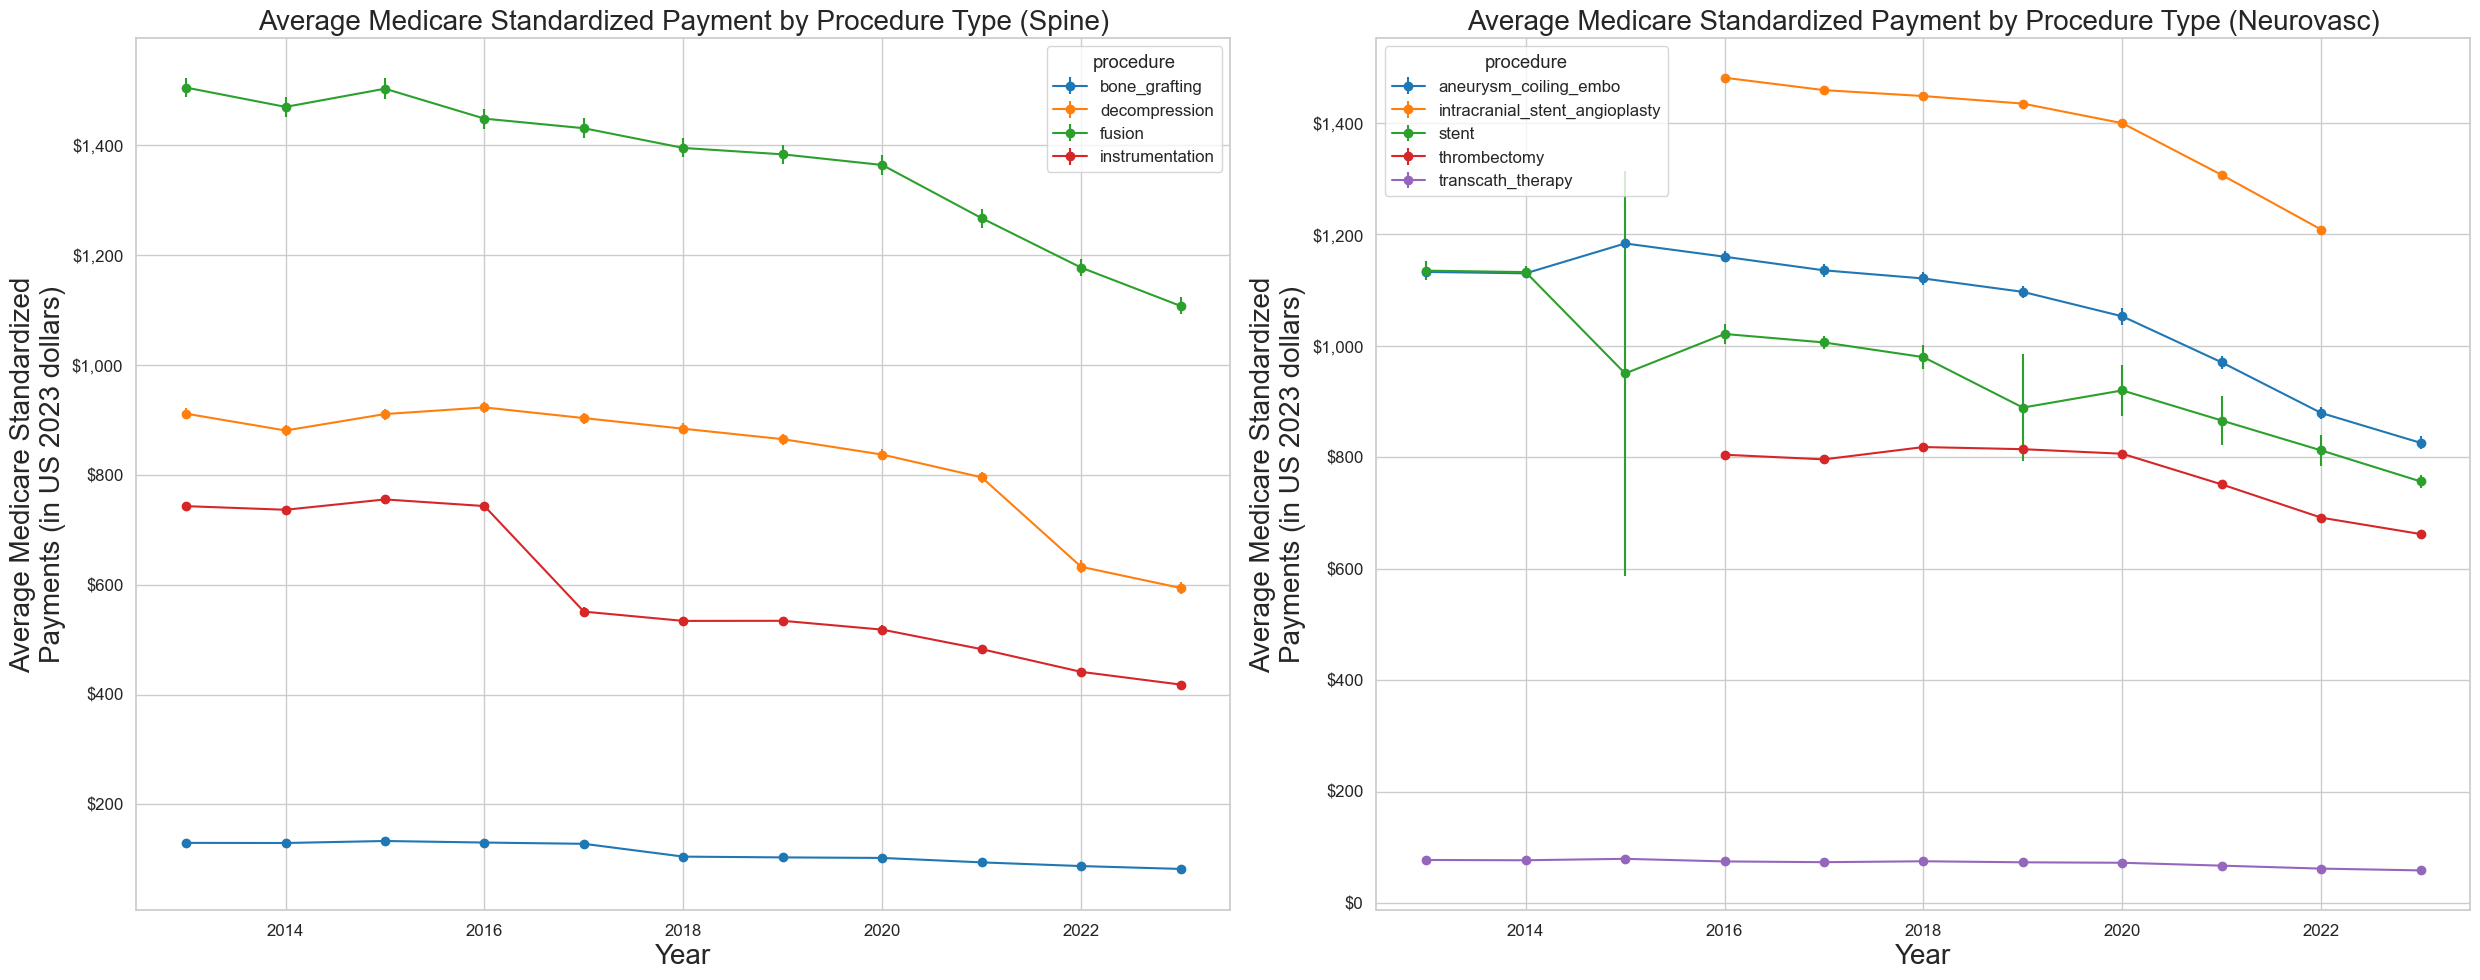

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Avg_Price_per_service_adj']
    
        # Compute error bars from CI bounds
        yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
        axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Average Medicare Standardized Payment by Procedure Type ({specialty_name[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

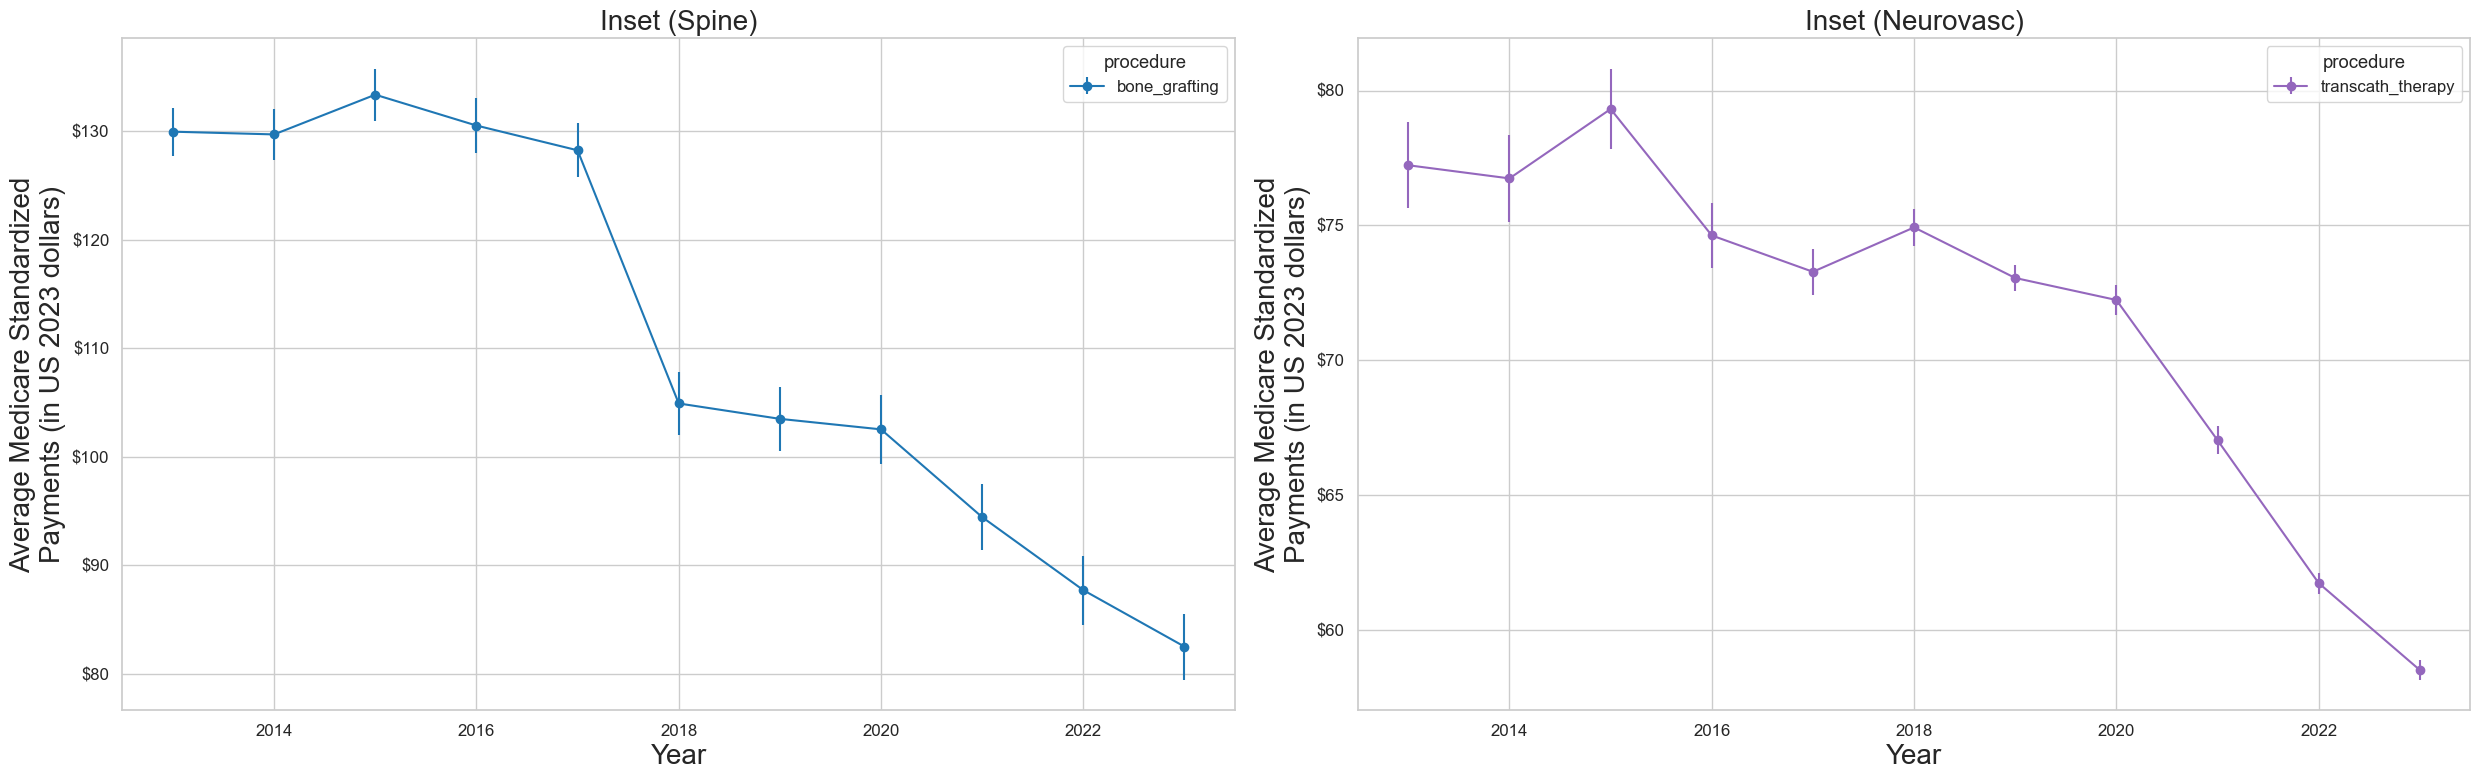

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(25, 8)) 
plot_inset = [
    ['fusion_cervical', 'bone_grafting', 'decompression_cervical', 'decompression_thoracic', 'fusion_thoracic', 'fusion_multiple_regions'],
    ["transcath_therapy", "intraarterial_pharm_infusion", "temp_balloon"]
]

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in plot_inset[i]:
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Avg_Price_per_service_adj']
        
            # Compute error bars from CI bounds
            yerr = [y - df_sorted['CI_lower_avg_price_per_service'], df_sorted['CI_upper_avg_price_per_service'] - y]
    
            axs[i].errorbar(x, y, yerr=yerr, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Average Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Average Standardized Payment Growth Rate

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57777/578492366.py:28: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100


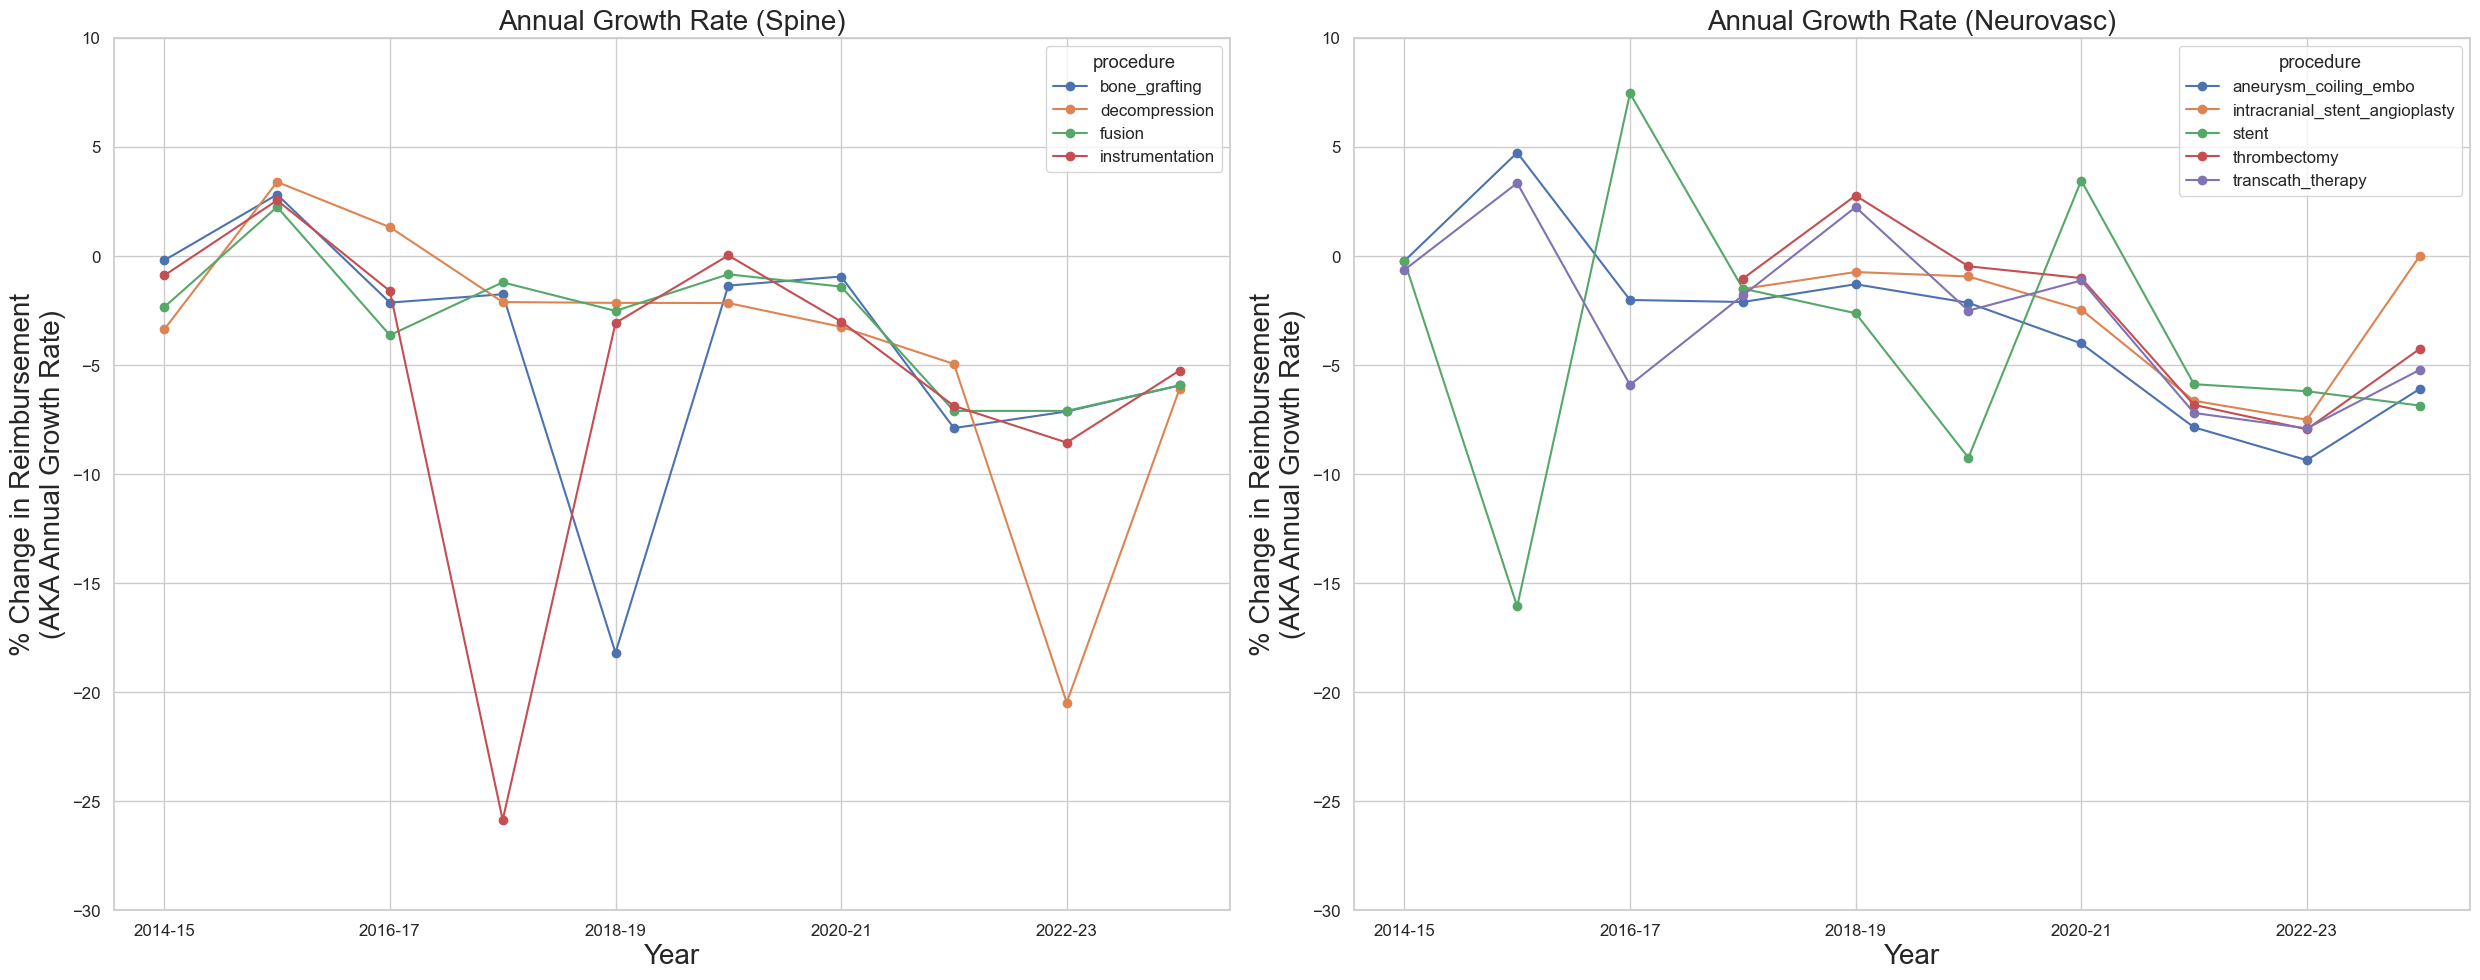

In [65]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Spine': [], 'Neurovasc': []}
aagr_no_interp = {'Spine': [], 'Neurovasc': []}
all_deltas = {'Spine': [], 'Neurovasc': []}

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100
        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta)])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23'])
    axs[i].set_ylabel("% Change in Reimbursement\n(AKA Annual Growth Rate)", fontsize=20)
    axs[i].set_ylim([-30, 10])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [48]:
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'AAGR (%)']).sort_values(by=['AAGR (%)'])

,procedure,AAGR (%)
3,instrumentation,-5.249871
0,bone_grafting,-4.267703
1,decompression,-3.978927
6,stent,-3.764250
4,aneurysm_coiling_embo,-3.033358
2,fusion,-2.978584
5,intracranial_stent_angioplasty,-2.822756
7,thrombectomy,-2.679421
8,transcath_therapy,-2.668189


In [227]:
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'AAGR (%)']).sort_values(by=['AAGR (%)']).to_csv("results/aagr_by_procedure.csv", index=False)

In [228]:
stats.ttest_ind([x[1] for x in aagr['Spine']], [x[1] for x in aagr['Neurovasc']])

Ttest_indResult(statistic=-2.3890615291867046, pvalue=0.04823529343071386)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_65716/621702277.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


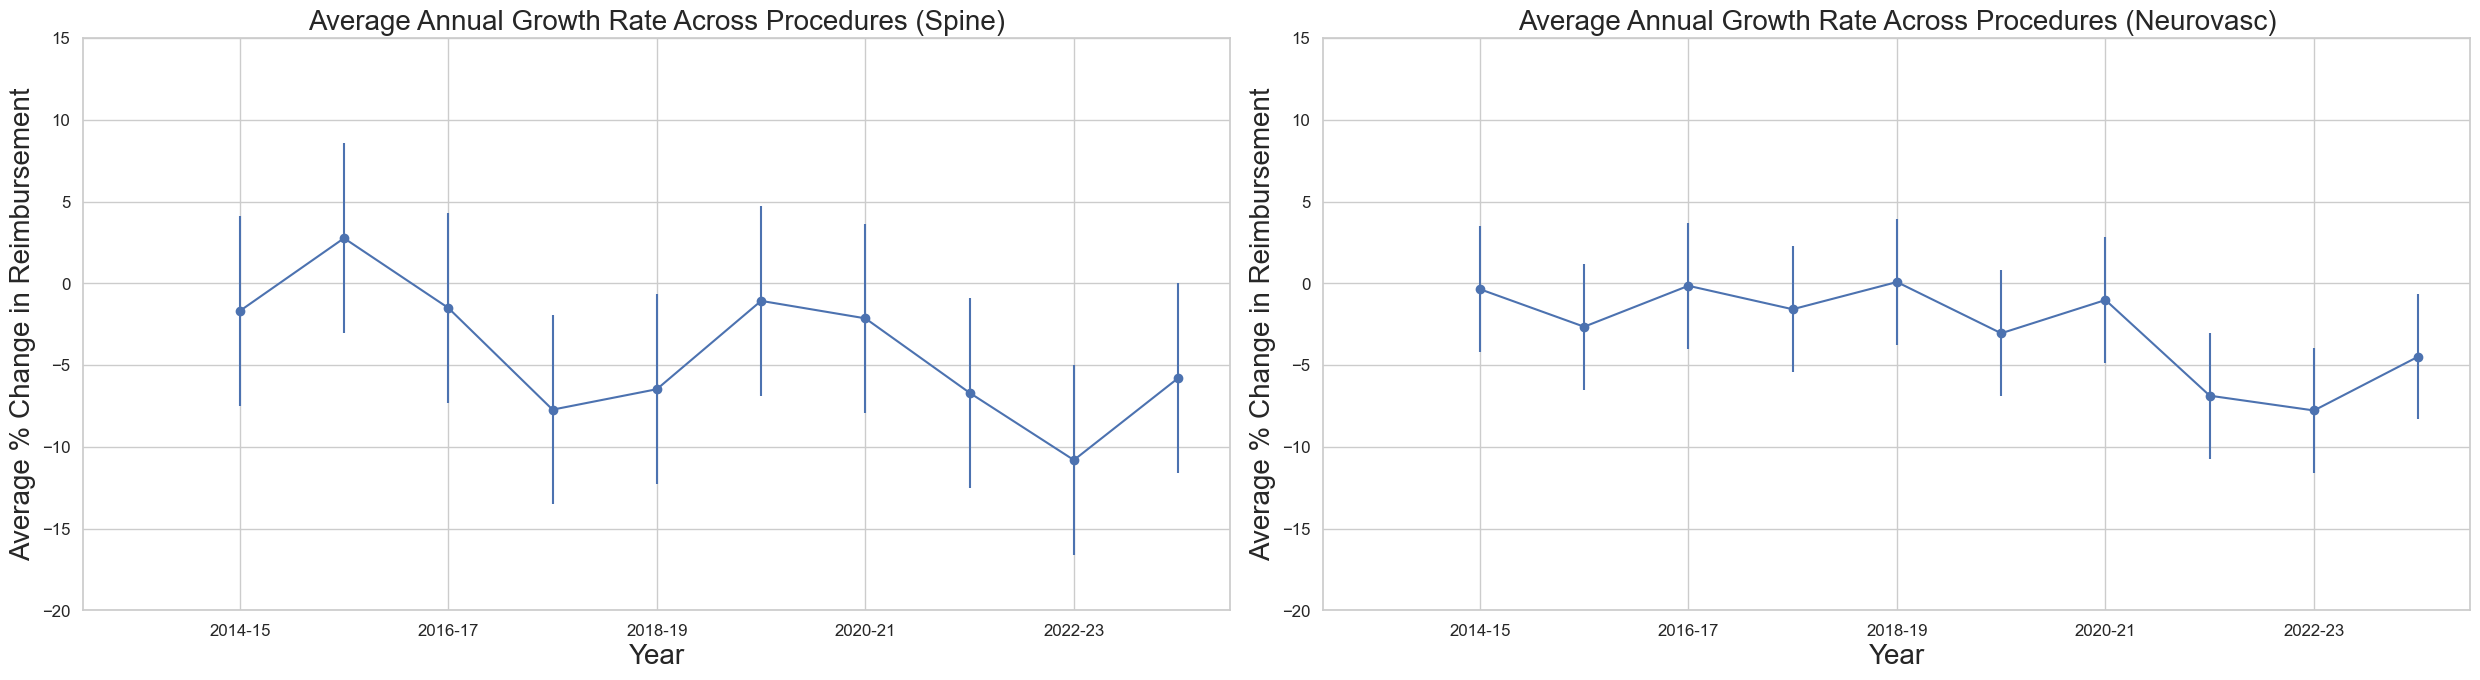

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Reimbursement", fontsize=20)
    axs[i].set_ylim([-20, 15])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})", fontsize=20)

    i += 1

plt.tight_layout()

In [230]:
aagr = {'Spine': [], 'Neurovasc': []}
aagr_no_interp = {'Spine': [], 'Neurovasc': []}
all_deltas = {'Spine': [], 'Neurovasc': []}

for i, specialty in enumerate([util_2023_2013_adj_spine_by_cpt, util_2023_2013_adj_neurovasc_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

In [231]:
pd.set_option('display.max_rows', None)
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['cpt', 'AAGR (%)', 'specialty']).sort_values(by=['AAGR (%)']).to_csv("results/aagr_by_cpt_code.csv", index=False)

## Average Standardized Payment $ Growth

In [29]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

# aagr = {'Spine': [], 'Neurovasc': []}
# aagr_no_interp = {'Spine': [], 'Neurovasc': []}
# all_deltas = {'Spine': [], 'Neurovasc': []}

# for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
#     grouped = specialty.groupby(groupby_key)
#     for label, df in grouped:
#         # Sort by year to ensure proper line plotting
#         df_sorted = df.sort_values('year')
        
#         x = df_sorted['year'].tolist()
#         y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
#         pairs = {x[i]: item for i, item in enumerate(y)}
    
#         x_new = list(range(2013, 2024))
    
#         y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
#         delta = pd.Series(y_new).interpolate().diff().to_numpy()

#         axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

#         # Use this to compute AAGR per procedure later
#         aagr[specialty_name[i]].append([label, np.nanmean(delta)])

#         # Compute a version of AAGR without interpolation
#         delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
#         aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

#         # Use this to plot average growth rate across procedures later
#         all_deltas[specialty_name[i]].append(delta)

#     axs[i].legend(title=groupby_key)
#     axs[i].set_xlabel("Year")
#     axs[i].set_xticks([1, 3, 5, 7, 9])
#     axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
#     axs[i].set_ylabel("$ Change in Reimbursement\n(AKA Annual $ Growth)")
#     axs[i].set_title(f"Annual $ Growth ({specialty_name[i]})")
#     axs[i].set_ylim([-200, 90])

#     axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

# plt.tight_layout()

In [233]:
# temp = pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'Change in $']).sort_values(by=['Change in $'])
# temp['Change in $'] = temp['Change in $'].apply(lambda x: f'${x:,.2f}'.format(x))

In [234]:
# stats.ttest_ind([x[1] for x in aagr['Spine']], [x[1] for x in aagr['Neurovasc']], alternative='less')

In [235]:
# fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

# i = 0
# for key, specialty in all_deltas.items():
#     aagr = np.nanmean(np.array(specialty), axis=0)
#     sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
#     ci_lower = aagr - 1.96 * sem
#     ci_upper = aagr + 1.96 * sem
    
#     # Compute error bars from CI bounds
#     yerr = [aagr - ci_lower, ci_upper - aagr]

#     axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

#     axs[i].set_xlabel("Year")
#     axs[i].set_xticks([1, 3, 5, 7, 9])
#     axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
#     axs[i].set_ylabel("Average $ Change in Reimbursement")
#     axs[i].set_ylim([-150, 100])
#     axs[i].set_title(f"Average Annual $ Growth Across Procedures ({specialty_name[i]})")

#     axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

#     i += 1

# plt.tight_layout()

## Total Payment

In [41]:
util_2023_2013_adj_spine['CI_lower_tot_pymt'] = util_2023_2013_adj_spine['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_spine['Tot_Pymt_adj_sem']
util_2023_2013_adj_spine['CI_upper_tot_pymt'] = util_2023_2013_adj_spine['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_spine['Tot_Pymt_adj_sem']

util_2023_2013_adj_neurovasc['CI_lower_tot_pymt'] = util_2023_2013_adj_neurovasc['Tot_Pymt_adj'] - 1.96 * util_2023_2013_adj_neurovasc['Tot_Pymt_adj_sem']
util_2023_2013_adj_neurovasc['CI_upper_tot_pymt'] = util_2023_2013_adj_neurovasc['Tot_Pymt_adj'] + 1.96 * util_2023_2013_adj_neurovasc['Tot_Pymt_adj_sem']

In [42]:
util_2023_2013_adj_spine[util_2023_2013_adj_spine['year'].isin([2013, 2023])].groupby('year')['Sum_Pymt_adj'].sum()

year
2013    2.931416e+08
2023    2.224916e+08
Name: Sum_Pymt_adj, dtype: float64

In [43]:
(1.080776e+08 - 1.528913e+08)/1.528913e+08

-0.2931082409528861

In [44]:
util_2023_2013_adj_neurovasc[util_2023_2013_adj_neurovasc['year'].isin([2013, 2023])].groupby('year')['Sum_Pymt_adj'].sum()

year
2013    1.748547e+06
2023    5.838183e+06
Name: Sum_Pymt_adj, dtype: float64

In [45]:
(5.838183e+06-1.748547e+06)/1.748547e+06

2.3388767931316687

NameError: name 'colors' is not defined

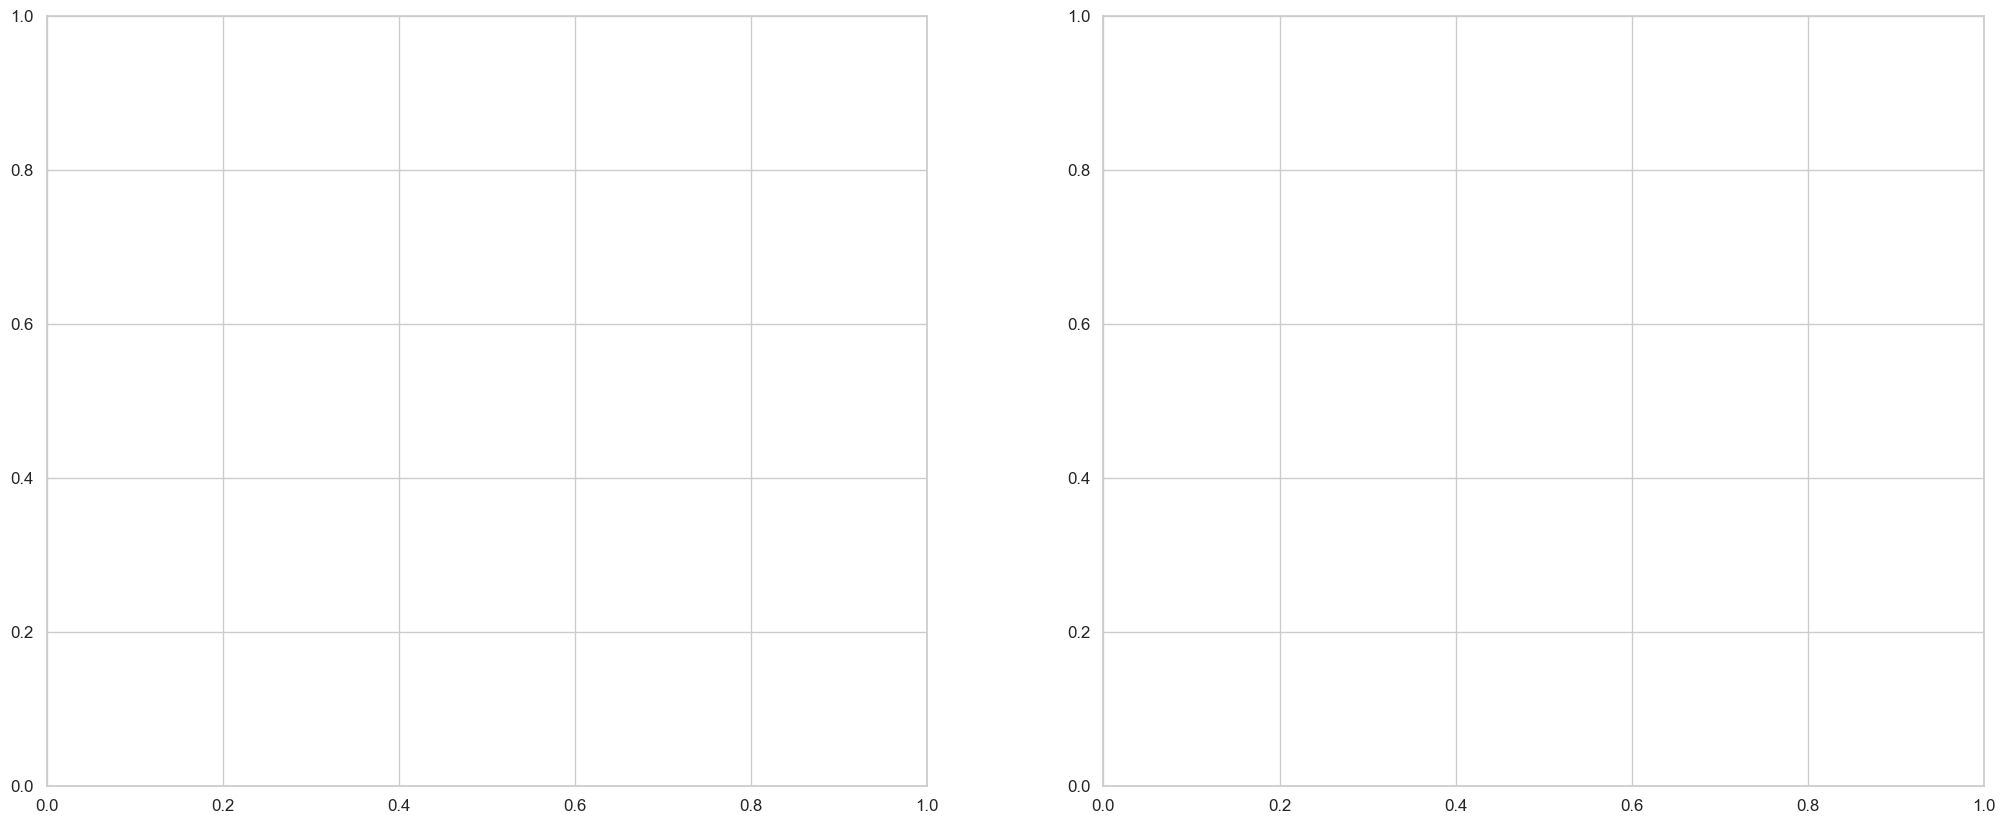

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0

    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year']
        y = df_sorted['Sum_Pymt_adj']
    
        axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        p_num += 1
    
    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Total Medicare Standardized Payment by Procedure Type ({specialty_name[i]})", fontsize=20)
    
    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

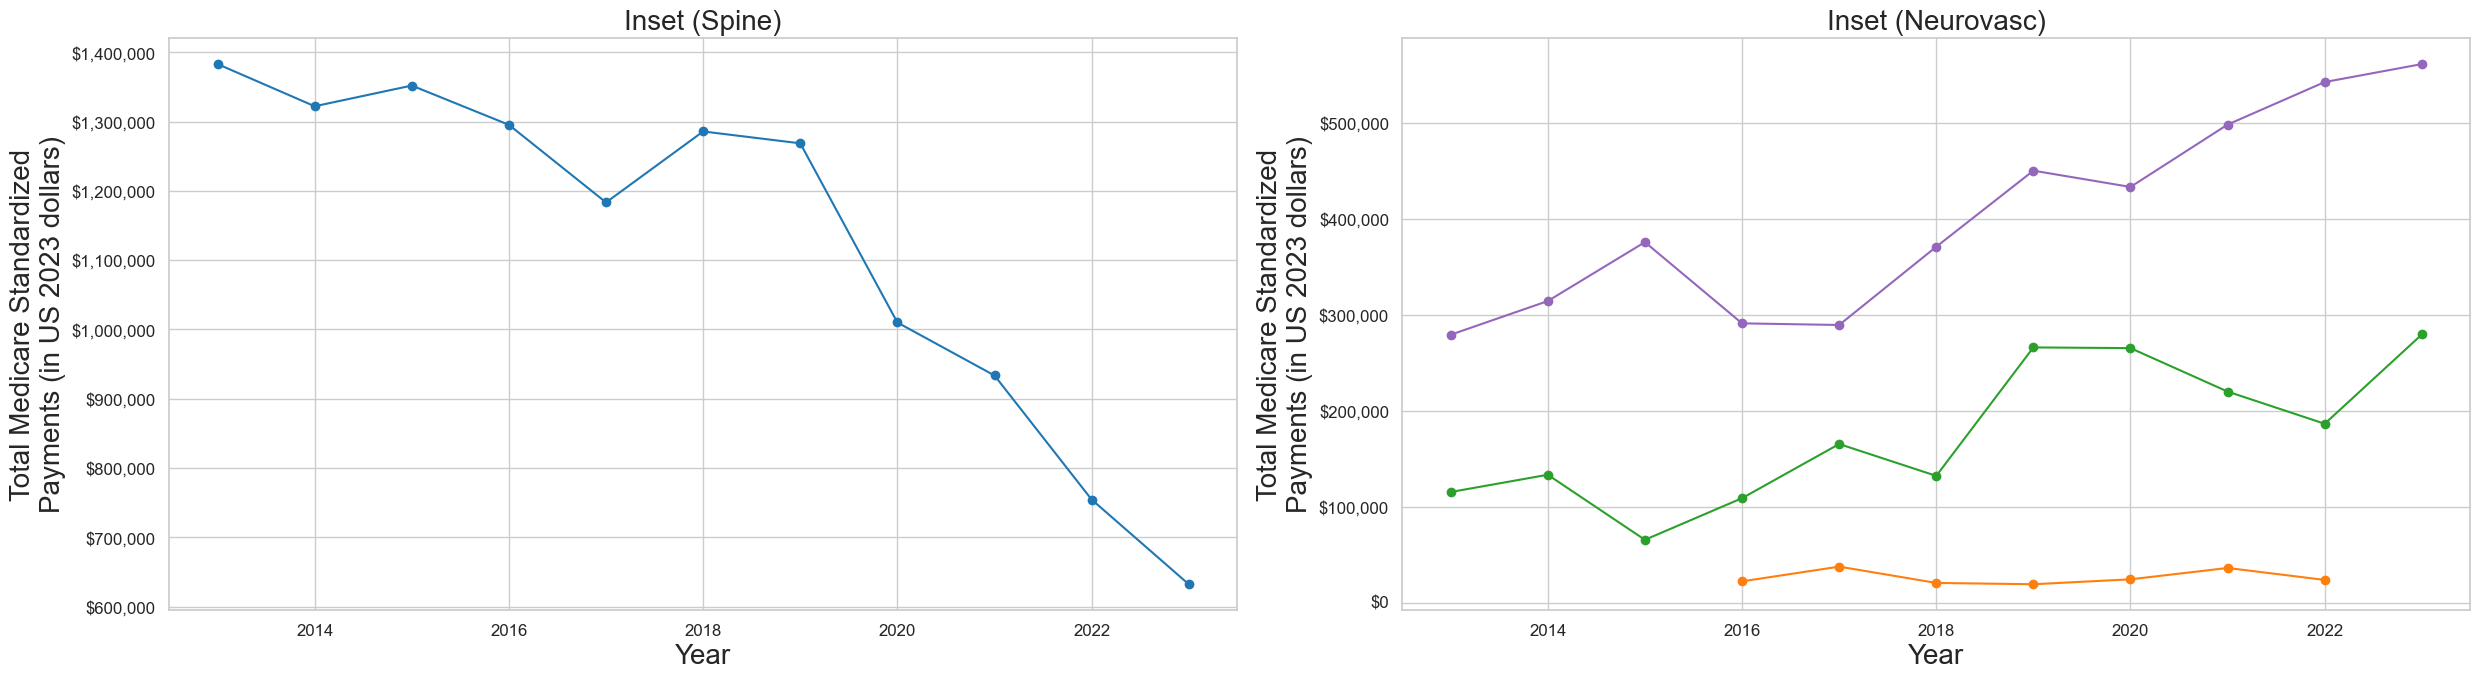

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 
plot_inset = [
    ['fusion_cervical', 'bone_grafting', 'decompression_cervical', 'decompression_thoracic', 'fusion_thoracic', 'fusion_multiple_regions'],
    ["intracranial_stent_angioplasty", "stent", "transcath_therapy", "intraarterial_pharm_infusion", "temp_balloon"]
]

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    p_num = 0
    
    for label, df in grouped:
        if label in plot_inset[i]:
            # Sort by year to ensure proper line plotting
            df_sorted = df.sort_values('year')
            
            x = df_sorted['year']
            y = df_sorted['Sum_Pymt_adj']
            axs[i].plot(x, y, label=label, marker='o', markersize=6, linestyle='-', color=colors[p_num])
        
        p_num += 1
    
    # axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_ylabel("Total Medicare Standardized\nPayments (in US 2023 dollars)", fontsize=20)
    axs[i].set_title(f"Inset ({specialty_name[i]})", fontsize=20)

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

## Total Payment Growth Rate

In [35]:
aagrs = {}
for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    aagr = (
        specialty.sort_values(['procedure', 'year'])
        .groupby('procedure')
        .apply(lambda g: g['Sum_Pymt_adj'].pct_change().mean() * 100)
        .reset_index(name='AAGR_%')
    )

    # Get average utilization per procedure as weights
    weights = specialty.groupby('procedure')['Sum_Pymt_adj'].mean()
    
    # Merge with AAGR result
    aagr_weighted = aagr.set_index('procedure').join(weights.rename('sum_pymt'))
    
    # Weighted average
    weighted_aagr = (aagr_weighted['AAGR_%'] * aagr_weighted['sum_pymt']).sum() / aagr_weighted['sum_pymt'].sum()
    
    aagrs[specialty_name[i]] = (aagr, weighted_aagr)

In [36]:
aagrs['Spine'][1], aagrs['Neurovasc'][1]

(-2.162913849170848, 15.03507192305849)

In [37]:
aagrs['Spine'][0]

,procedure,AAGR_%
0,bone_grafting,-6.212901
1,decompression,-5.731760
2,fusion,-2.400060
3,instrumentation,2.445858


In [38]:
aagrs['Neurovasc'][0]

,procedure,AAGR_%
0,aneurysm_coiling_embo,10.065279
1,intracranial_stent_angioplasty,9.800516
2,stent,18.166549
3,thrombectomy,23.997230
4,transcath_therapy,8.216715


In [39]:
stats.ttest_ind(aagrs['Spine'][0]['AAGR_%'], aagrs['Neurovasc'][0]['AAGR_%'])

Ttest_indResult(statistic=-4.411449331906652, pvalue=0.0031133462626275034)

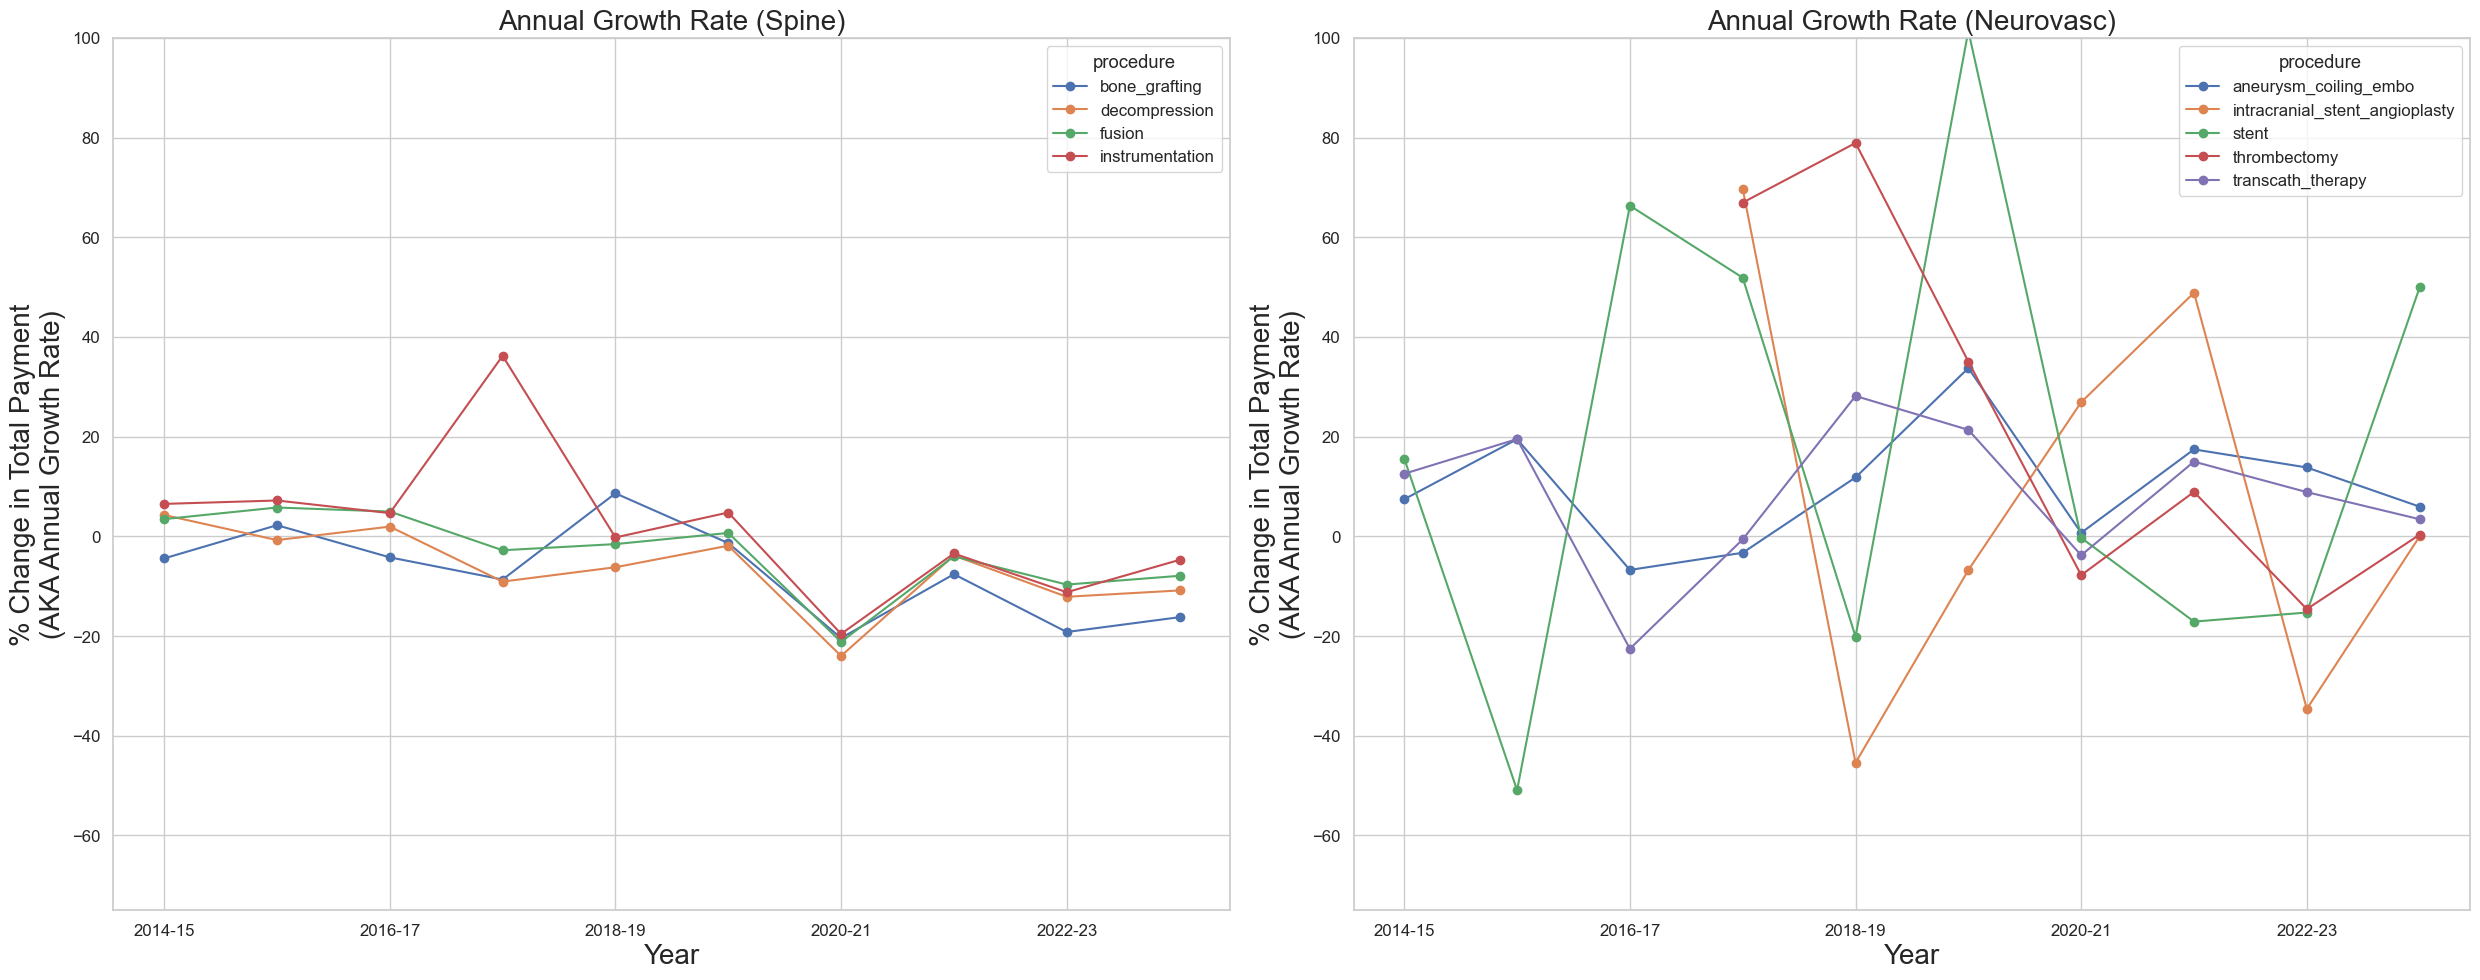

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Spine': [], 'Neurovasc': []}
aagr_no_interp = {'Spine': [], 'Neurovasc': []}
all_deltas = {'Spine': [], 'Neurovasc': []}

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta)])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("% Change in Total Payment\n(AKA Annual Growth Rate)", fontsize=20)
    axs[i].set_ylim([-75, 100])
    axs[i].set_title(f"Annual Growth Rate ({specialty_name[i]})", fontsize=20)

plt.tight_layout()

In [240]:
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'AAGR (%)']).sort_values(by=['AAGR (%)'])

,procedure,AAGR (%)
0,bone_grafting,-7.098320
1,decompression,-6.227648
2,fusion,-3.199313
3,instrumentation,2.040695
8,transcath_therapy,8.216715
5,intracranial_stent_angioplasty,8.400442
4,aneurysm_coiling_embo,10.065279
6,stent,18.166549
7,thrombectomy,23.997230


In [241]:
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'AAGR (%)']).sort_values(by=['AAGR (%)']).to_csv("results/aagr_total_pymt_by_procedure.csv", index=False)

In [242]:
stats.ttest_ind([x[1] for x in aagr['Spine']], [x[1] for x in aagr['Neurovasc']])

Ttest_indResult(statistic=-4.351515303512333, pvalue=0.0033486562666201224)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_65716/3897824675.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


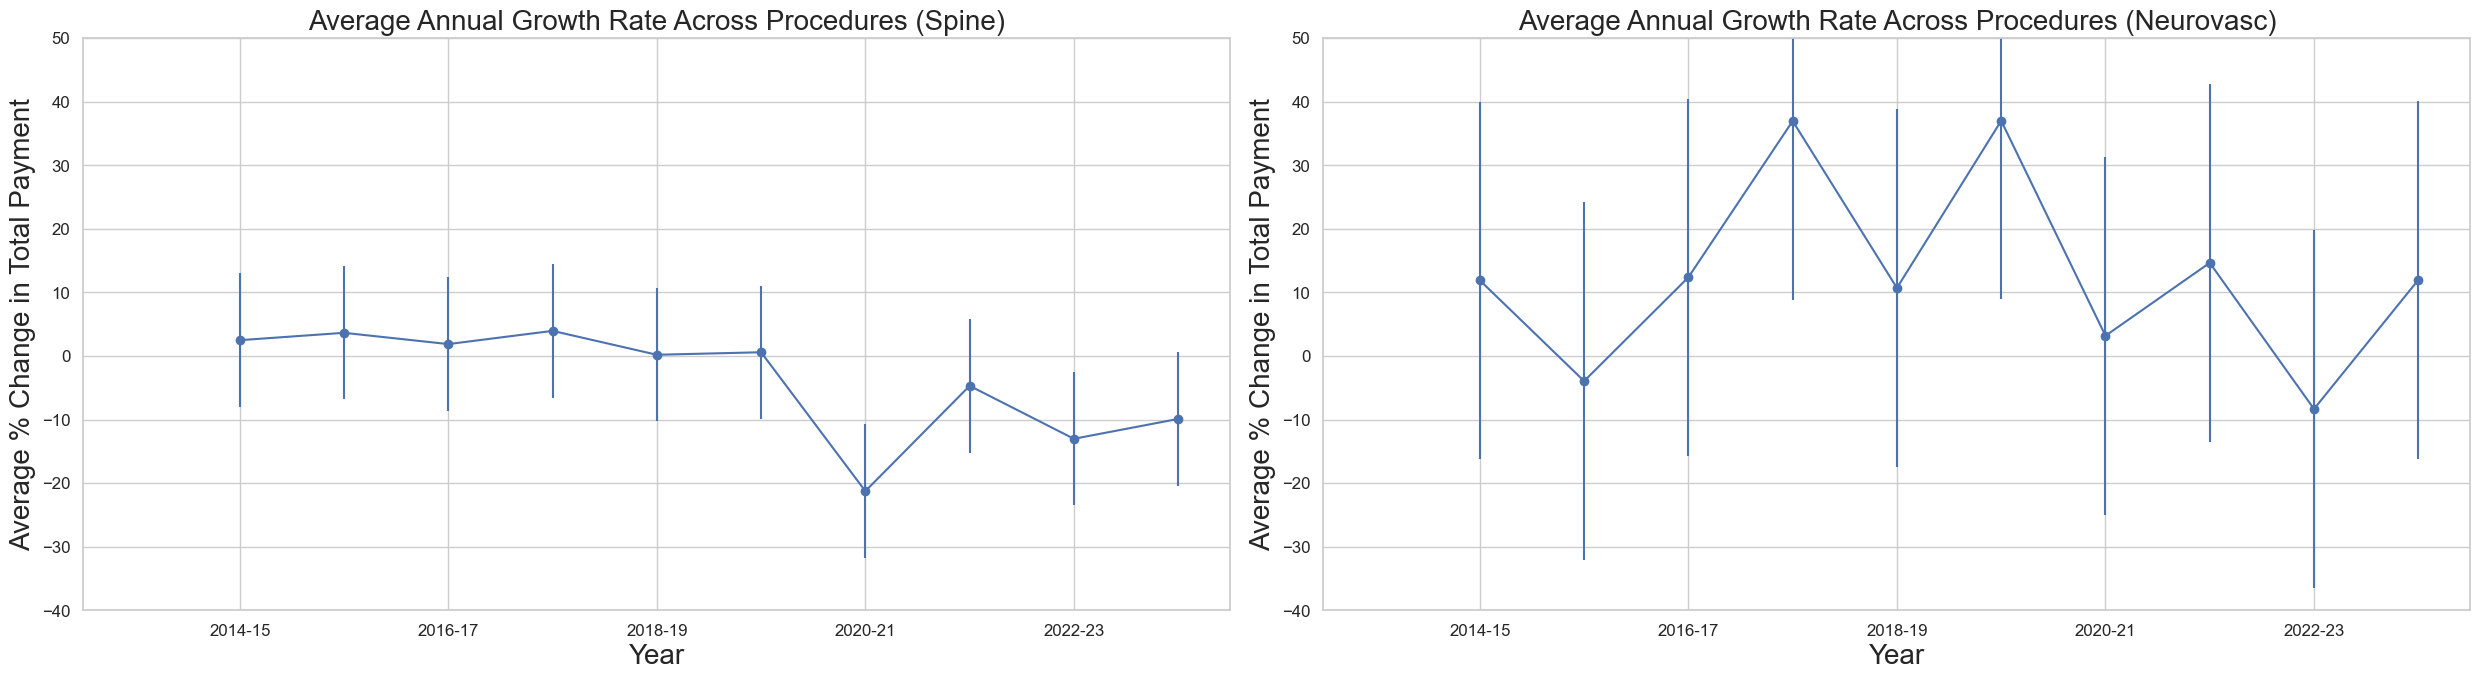

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year", fontsize=20)
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average % Change in Total Payment", fontsize=20)
    axs[i].set_ylim([-40, 50])
    axs[i].set_title(f"Average Annual Growth Rate Across Procedures ({specialty_name[i]})", fontsize=20)

    i += 1

plt.tight_layout()

In [244]:
aagr = {'Spine': [], 'Neurovasc': []}
aagr_no_interp = {'Spine': [], 'Neurovasc': []}
all_deltas = {'Spine': [], 'Neurovasc': []}

for i, specialty in enumerate([util_2023_2013_adj_spine_by_cpt, util_2023_2013_adj_neurovasc_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta), specialty_name[i]])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

In [245]:
pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['cpt', 'AAGR (%)', 'specialty']).sort_values(by=['AAGR (%)']).to_csv("results/aagr_total_pymt_by_cpt_code.csv", index=False)

## Total Payment $ Growth

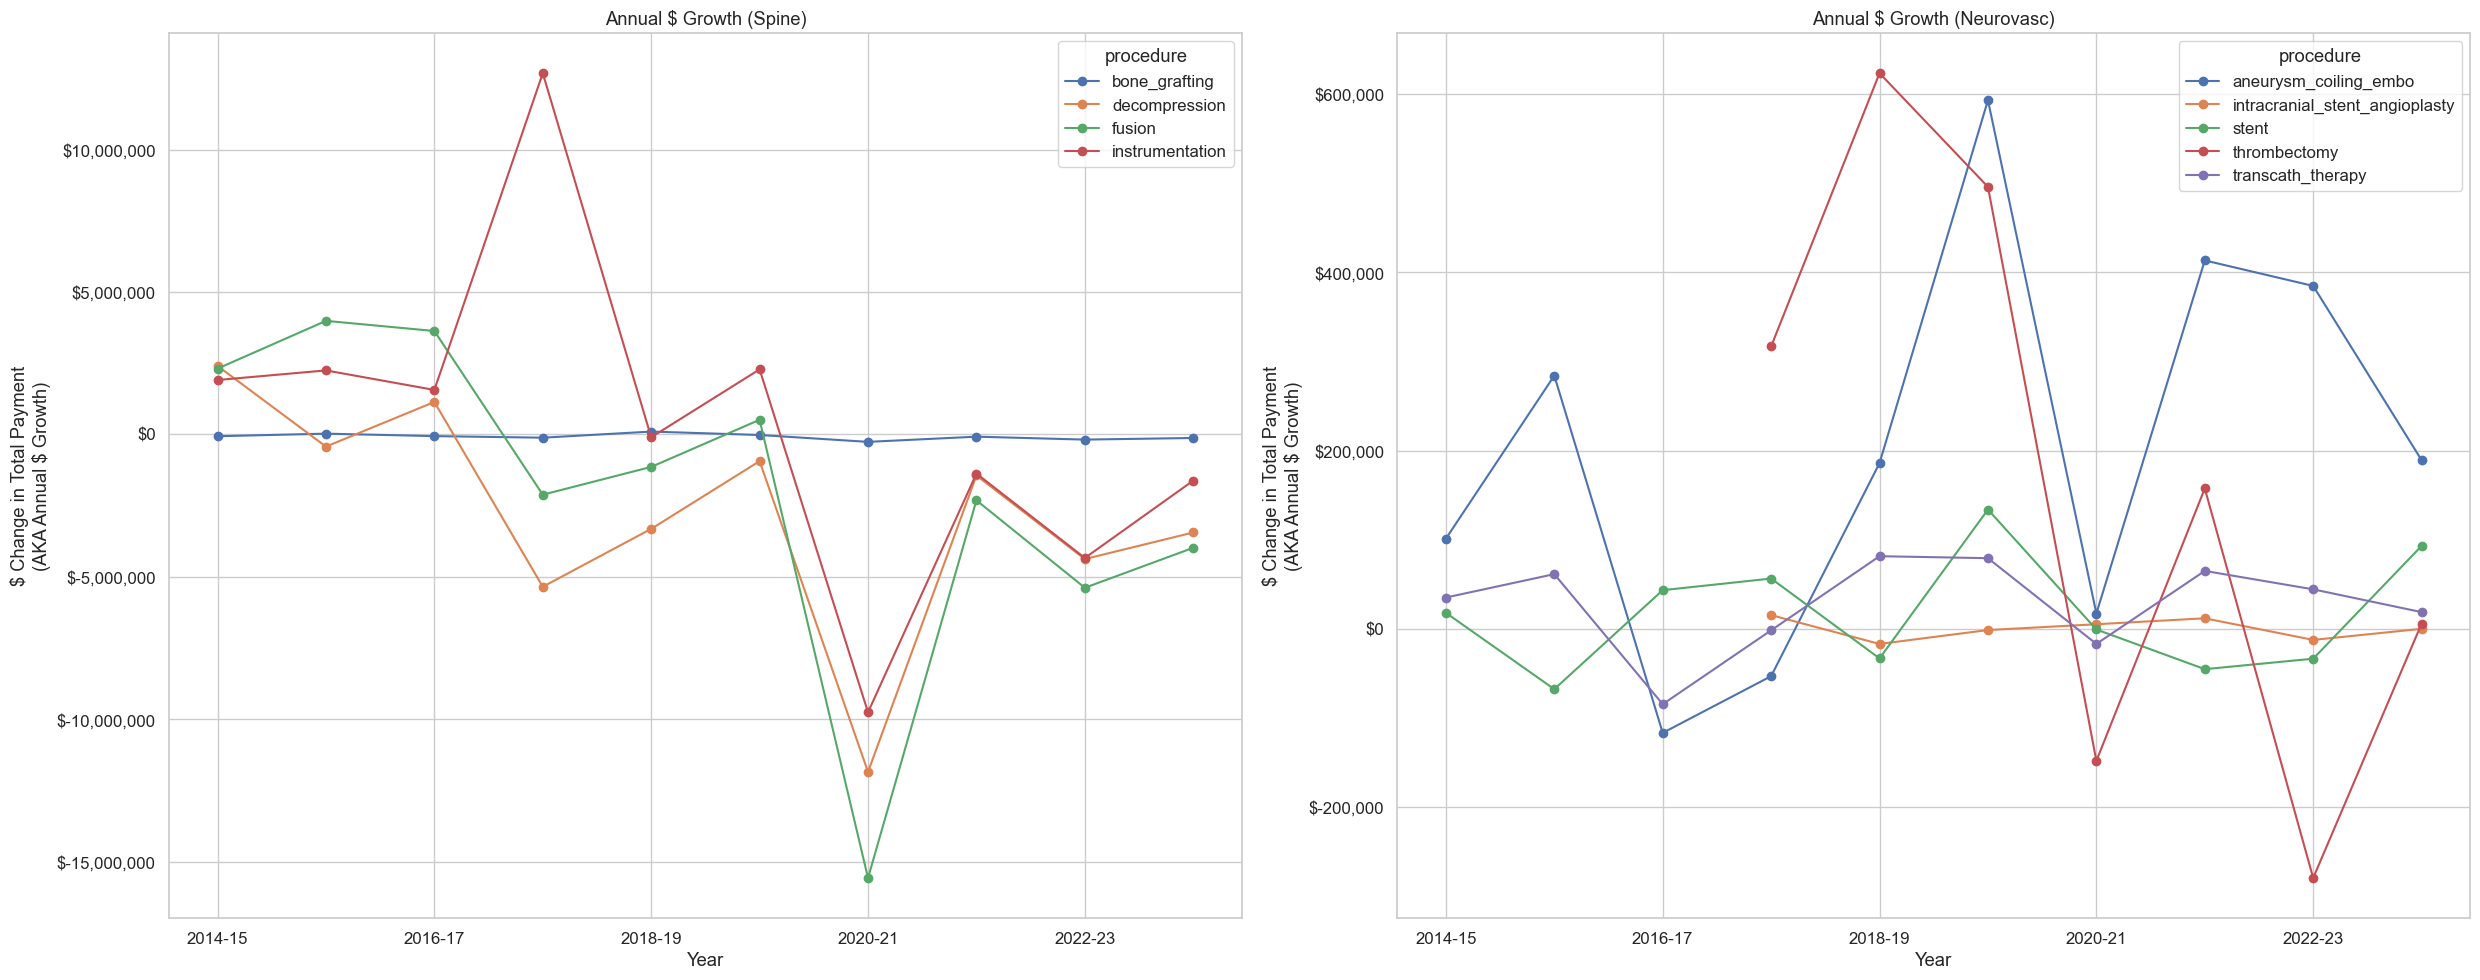

In [246]:
fig, axs = plt.subplots(1, 2, figsize=(25, 10)) 

aagr = {'Spine': [], 'Neurovasc': []}
aagr_no_interp = {'Spine': [], 'Neurovasc': []}
all_deltas = {'Spine': [], 'Neurovasc': []}

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[i]: item for i, item in enumerate(y)}
    
        x_new = list(range(2013, 2024))
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().diff().to_numpy()

        axs[i].plot(range(len(delta)), delta, label=label, marker='o', markersize=6, linestyle='-')

        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]].append([label, np.nanmean(delta)])

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]].append([label, np.nanmean(delta_no_interp)])

        # Use this to plot average growth rate across procedures later
        all_deltas[specialty_name[i]].append(delta)

    axs[i].legend(title=groupby_key)
    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("$ Change in Total Payment\n(AKA Annual $ Growth)")
    axs[i].set_title(f"Annual $ Growth ({specialty_name[i]})")

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()

In [247]:
temp = pd.DataFrame(aagr['Spine'] + aagr['Neurovasc'], columns=['procedure', 'Change in $']).sort_values(by=['Change in $'])
temp['Change in $'] = temp['Change in $'].apply(lambda x: f'${x:,.2f}'.format(x))
temp

,procedure,Change in $
1,decompression,"$-2,755,436.57"
2,fusion,"$-2,002,998.59"
0,bone_grafting,"$-75,063.52"
5,intracranial_stent_angioplasty,$213.68
6,stent,"$16,410.55"
8,transcath_therapy,"$28,194.05"
7,thrombectomy,"$167,375.28"
4,aneurysm_coiling_embo,"$199,901.81"
3,instrumentation,"$352,129.64"


In [248]:
aagr_total_pymt = aagr

In [249]:
stats.ttest_ind([x[1] for x in aagr['Spine']], [x[1] for x in aagr['Neurovasc']], alternative='less')

Ttest_indResult(statistic=-1.8260787684903064, pvalue=0.05528955641791578)

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57422/2937180287.py:5: RuntimeWarning: Mean of empty slice
  aagr = np.nanmean(np.array(specialty), axis=0)


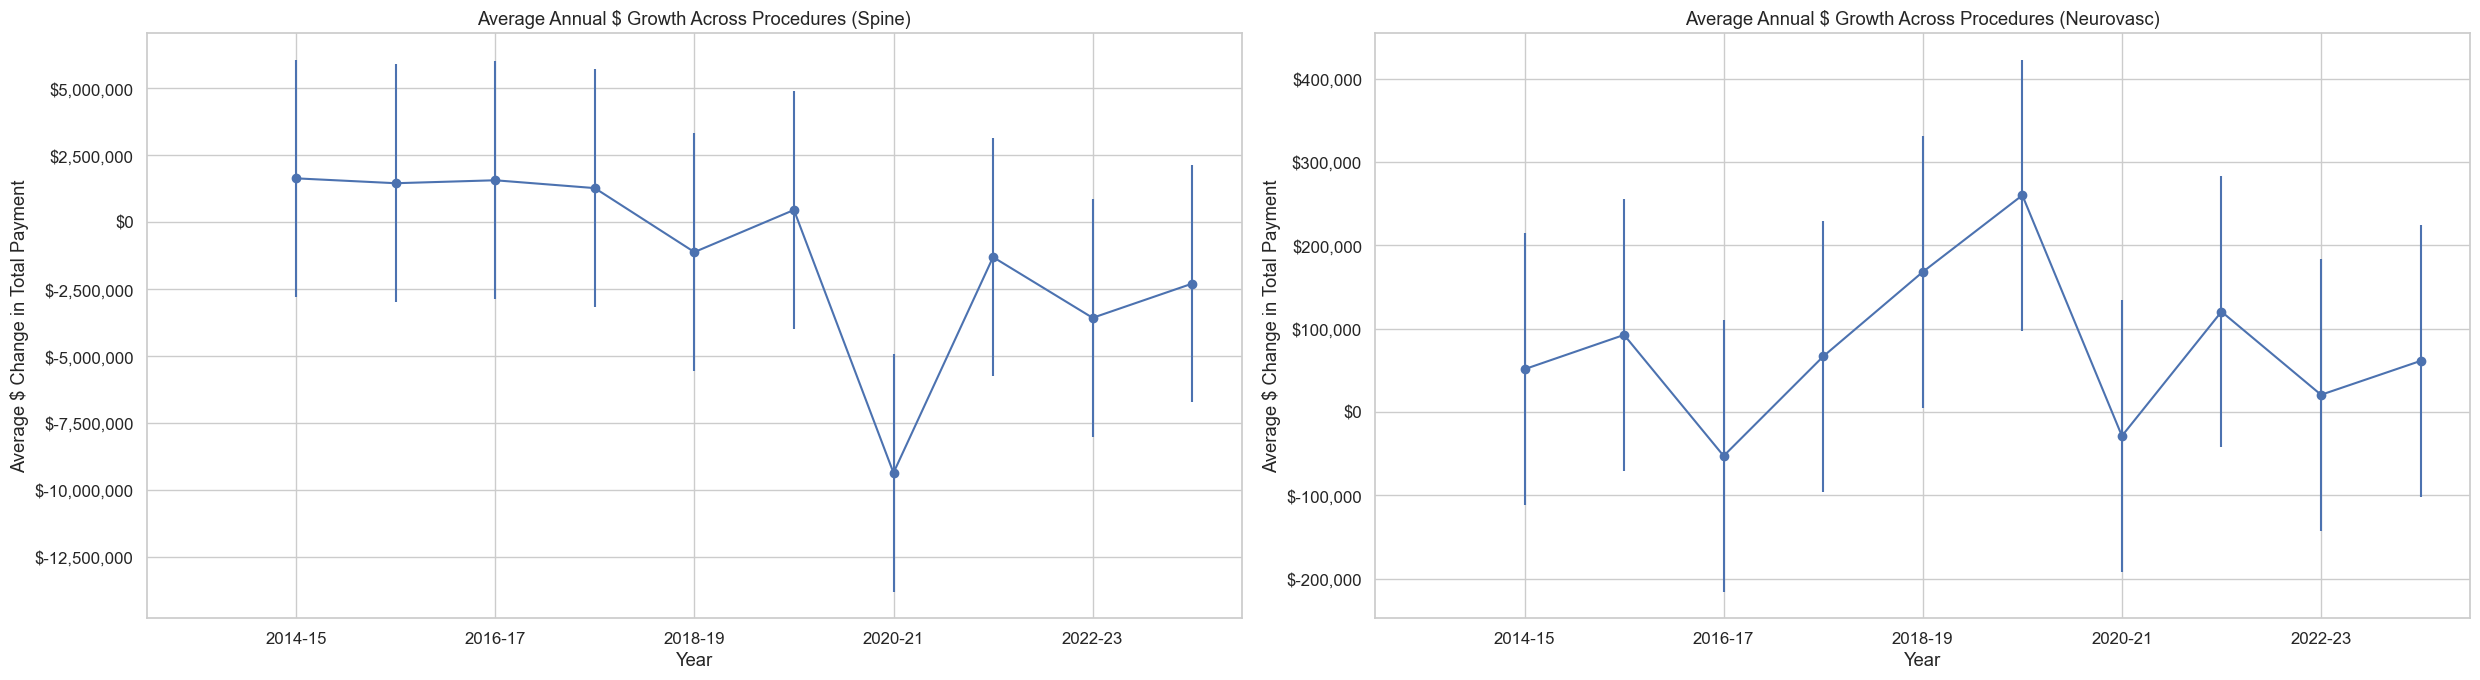

In [250]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7)) 

i = 0
for key, specialty in all_deltas.items():
    aagr = np.nanmean(np.array(specialty), axis=0)
    sem = np.nanstd(np.array(specialty), ddof=1) / np.sqrt(len(specialty))
    
    ci_lower = aagr - 1.96 * sem
    ci_upper = aagr + 1.96 * sem
    
    # Compute error bars from CI bounds
    yerr = [aagr - ci_lower, ci_upper - aagr]

    axs[i].errorbar(range(len(aagr)), aagr, yerr=yerr,  marker='o', markersize=6, linestyle='-')

    axs[i].set_xlabel("Year")
    axs[i].set_xticks([1, 3, 5, 7, 9])
    axs[i].set_xticklabels(['2014-15', '2016-17', '2018-19', '2020-21', '2022-23']),
    axs[i].set_ylabel("Average $ Change in Total Payment")
    # axs[i].set_ylim([-150, 100])
    axs[i].set_title(f"Average Annual $ Growth Across Procedures ({specialty_name[i]})")

    axs[i].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))

    i += 1

plt.tight_layout()

# Linear Regression

In [21]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

In [22]:
def sklearn_linear_pvalues(model, X, y):
    """
    Compute OLS-style SEs, t-stats, and p-values for a fitted sklearn LinearRegression.
    Works only for unregularized linear models (no Ridge/Lasso).

    Parameters
    ----------
    model : sklearn.linear_model.LinearRegression (already .fit())
    X : pandas.DataFrame or numpy array (the SAME features the model was fit on)
    y : pandas Series or numpy array (target used for fitting)

    Returns
    -------
    pandas.DataFrame with columns: term, coef, se, t, p
    """
    X_arr = np.asarray(X, dtype=float)
    y_arr = np.asarray(y, dtype=float).ravel()

    # Build design matrix (add intercept column if model has an intercept)
    if getattr(model, "fit_intercept", False):
        X_design = np.column_stack([np.ones(X_arr.shape[0]), X_arr])
        coef = np.r_[model.intercept_, model.coef_]
        names = ["Intercept"] + (list(X.columns) if hasattr(X, "columns") else [f"x{i}" for i in range(X_arr.shape[1])])
    else:
        X_design = X_arr
        coef = np.asarray(model.coef_).ravel()
        names = list(X.columns) if hasattr(X, "columns") else [f"x{i}" for i in range(X_arr.shape[1])]

    # Predictions & residuals
    y_hat = X_design @ coef
    resid = y_arr - y_hat

    n, p = X_design.shape
    dof = n - p
    if dof <= 0:
        raise ValueError("Not enough degrees of freedom to compute standard errors (n <= p).")

    # Residual variance (sigma^2) and covariance of coefficients
    sigma2 = (resid @ resid) / dof
    # Use pinv to be robust to near-collinearity
    XtX_inv = np.linalg.pinv(X_design.T @ X_design)
    cov = sigma2 * XtX_inv

    se = np.sqrt(np.diag(cov))
    t_stats = coef / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), dof))

    return pd.DataFrame({"term": names, "coef": coef, "se": se, "t": t_stats, "p": p_vals})


## Linear Regression by Procedure

In [29]:
specialty_name = ["Spine", "Neurovasc"]
aagr = {'Spine': {}, 'Neurovasc': {}}
aagr_no_interp = {'Spine': {}, 'Neurovasc': {}}

x_years = list(range(2020, 2024)) # list(range(2013, 2024))

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[k]: item for k, item in enumerate(y)}
        x_new = x_years
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy()  * 100
        
        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]][label] = delta

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]][label] = delta_no_interp

In [30]:
aagr_for_df = []
years = x_years
for specialty, data in aagr.items():
    for proc, delta in data.items():
        aagr_for_df.extend([[years[i], proc, delta[i]] for i in range(len(delta))])

aagr_df = pd.DataFrame(aagr_for_df, columns=["year", "procedure", "Avg_Price_per_service_change"])

aagr_df_spine = util_2023_2013_adj_spine.merge(aagr_df, on=["procedure", "year"])
aagr_df_neurovasc = util_2023_2013_adj_neurovasc.merge(aagr_df, on=["procedure", "year"])

In [31]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'Avg_Price_per_service_change']]
spine_data_for_regression = pd.get_dummies(spine_data_for_regression, columns=['procedure'])
# spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'Avg_Price_per_service_change']]
neurovasc_data_for_regression = pd.get_dummies(neurovasc_data_for_regression, columns=['procedure'])
# neurovasc_data_for_regression['specialty'] = 1

In [32]:
all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True)
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_change'])

In [33]:
X = all_regression_data.drop(columns=['Avg_Price_per_service_change']).fillna(False)
y = all_regression_data['Avg_Price_per_service_change']

In [34]:
model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.8f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by='coef')

,term,coef,p
0,Intercept,-1047.830831,0.49899142
3,procedure_decompression,-3.272060,0.98472624
6,procedure_aneurysm_coiling_embo,-0.536131,0.99749721
2,procedure_bone_grafting,0.249470,0.99883541
5,procedure_instrumentation,0.341194,0.99840722
7,procedure_intracranial_stent_angioplasty,0.420134,0.99803390
10,procedure_transcath_therapy,0.460092,0.99785218
1,year,0.514639,0.54504653
4,procedure_fusion,0.522782,0.99755953
9,procedure_thrombectomy,0.890644,0.99584227


In [35]:
summary[['term', 'coef', 'p']].to_csv("results/spine_vs_neurovasc_regression_procedure_postcovid.csv", index=False)

In [36]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'Avg_Price_per_service_change']]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'Avg_Price_per_service_change']]
neurovasc_data_for_regression['specialty'] = 1

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_81847/3912402820.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_81847/3912402820.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [37]:
all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True)
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_change'])

In [38]:
X = all_regression_data.drop(columns=['Avg_Price_per_service_change', 'procedure']).fillna(False)
y = all_regression_data['Avg_Price_per_service_change']

In [39]:
model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.8f}'.format(x)) 
summary[['term', 'coef', 'p']]

,term,coef,p
0,Intercept,-1049.853531,0.48157001
1,year,0.515372,0.48478558
2,specialty,0.972257,0.41683527


## Linear Regression by CPT Code

In [15]:
# # Group by procedure and year, and summarize
# cpt_2023_2013_adj_spine = (
#     spine_data
#     .groupby(['HCPCS_Cd', 'year'], as_index=False)
#     .agg(
#         Sum_Utilization=('Tot_Srvcs', 'sum'),
#         Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
#         Sum_Pymt=('Tot_Pymt', 'sum'),
#         Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
#         Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
#         Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
#         Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
#         Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
#         Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
#         Sum_Provider=('Rndrng_NPI', lambda x: x.nunique())
#     )
# )

# cpt_2023_2013_adj_neurovasc = (
#     neurovasc_data
#     .groupby(['HCPCS_Cd', 'year'], as_index=False)
#     .agg(
#         Sum_Utilization=('Tot_Srvcs', 'sum'),
#         Sum_Spend=('Tot_Srvcs_Spend', 'sum'),
#         Sum_Pymt=('Tot_Pymt', 'sum'),
#         Sum_Spend_adj=('Tot_Srvcs_Spend_adj', 'sum'),
#         Sum_Pymt_adj=('Tot_Pymt_adj', 'sum'),
#         Avg_Price_per_service_adj=('Avg_Mdcr_Stdzd_Amt_adj', 'mean'),
#         Avg_Price_per_service_adj_sem=('Avg_Mdcr_Stdzd_Amt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
#         Tot_Pymt_adj=('Tot_Pymt_adj', 'mean'), # Tot_Pymt is actually Avg_Pymt, bad naming
#         Tot_Pymt_adj_sem=('Tot_Pymt_adj', lambda x: np.std(x, ddof=1) / np.sqrt(len(x))),
#         Sum_Provider=('Rndrng_NPI', lambda x: x.nunique()))
# )

In [106]:
specialty_name = ["Spine", "Neurovasc"]
aagr = {'Spine': {}, 'Neurovasc': {}}
aagr_no_interp = {'Spine': {}, 'Neurovasc': {}}

x_years = list(range(2013, 2024)) # list(range(2013, 2024))

for i, specialty in enumerate([util_2023_2013_adj_spine_by_cpt, util_2023_2013_adj_neurovasc_by_cpt]):
    grouped = specialty.groupby('HCPCS_Cd')
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Avg_Price_per_service_adj'].tolist()
    
        pairs = {x[k]: item for k, item in enumerate(y)}
        x_new = x_years
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().pct_change().to_numpy() * 100
        
        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]][label] = delta

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]][label] = delta_no_interp

In [107]:
aagr_for_df = []
years = x_years
for specialty, data in aagr.items():
    for proc, delta in data.items():
        aagr_for_df.extend([[years[i], proc, delta[i]] for i in range(len(delta))])

aagr_df = pd.DataFrame(aagr_for_df, columns=["year", "HCPCS_Cd", "Avg_Price_per_service_change"])

aagr_df_spine = util_2023_2013_adj_spine_by_cpt.merge(aagr_df, on=["HCPCS_Cd", "year"])
aagr_df_neurovasc = util_2023_2013_adj_neurovasc_by_cpt.merge(aagr_df, on=["HCPCS_Cd", "year"])

In [108]:
# spine_data_for_regression = util_2023_2013_adj_spine[['HCPCS_Cd', 'year', 'Avg_Price_per_service_adj', 'Sum_Pymt_adj']]
# spine_data_for_regression = pd.get_dummies(spine_data_for_regression, columns=['HCPCS_Cd'])
# spine_data_for_regression['specialty'] = 0

# neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['HCPCS_Cd', 'year', 'Avg_Price_per_service_adj', 'Sum_Pymt_adj']]
# neurovasc_data_for_regression = pd.get_dummies(neurovasc_data_for_regression, columns=['HCPCS_Cd'])
# neurovasc_data_for_regression['specialty'] = 1

In [109]:
spine_data_for_regression = aagr_df_spine[['HCPCS_Cd', 'year', 'Avg_Price_per_service_change']]
spine_data_for_regression = pd.get_dummies(spine_data_for_regression, columns=['HCPCS_Cd'])

neurovasc_data_for_regression = aagr_df_neurovasc[['HCPCS_Cd', 'year', 'Avg_Price_per_service_change']]
neurovasc_data_for_regression = pd.get_dummies(neurovasc_data_for_regression, columns=['HCPCS_Cd'])

In [110]:
all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True)
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_change'])

In [111]:
# X = all_regression_data.drop(columns=['Sum_Pymt_adj']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
# y = all_regression_data['Sum_Pymt_adj']

# model = LinearRegression()
# model.fit(X, y)

# # Coefficients & intercept
# # print("Intercept:", model.intercept_)
# # print("Coefficients:", model.coef_)

# feature_weights = []
# for i, coef in enumerate(model.coef_):
#     feature_weights.append([model.feature_names_in_[i], coef])

# feature_weights = pd.DataFrame(feature_weights, columns=['Feature Name', 'Weight'])
# feature_weights['Weight'] = feature_weights['Weight'].map('{:.2f}'.format)
# feature_weights.tail(n=24)

In [112]:
X = all_regression_data.drop(columns=['Avg_Price_per_service_change']).fillna(False)
y = all_regression_data['Avg_Price_per_service_change']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.8f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by='coef')

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_76098/1555789074.py:44: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(cov))


,term,coef,p
12,HCPCS_Cd_22556,-2.199823e+13,nan
47,HCPCS_Cd_63016,-3.156358e+08,0.00000000
15,HCPCS_Cd_22590,-3.156358e+08,0.00000000
82,HCPCS_Cd_37236,-3.156358e+08,0.00000000
6,HCPCS_Cd_22532,-3.156358e+08,0.00000000
...,...,...,...
41,HCPCS_Cd_62380,-3.156358e+08,0.00000000
49,HCPCS_Cd_63020,-3.156358e+08,0.00000000
61,HCPCS_Cd_63053,-3.156358e+08,0.00000000
1,year,-7.592196e-01,0.00001186


In [29]:
X = spine_data_for_regression.drop(columns=['Sum_Pymt_adj', 'specialty']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
y = spine_data_for_regression['Sum_Pymt_adj']

model = LinearRegression()
model.fit(X, y)

# Coefficients & intercept
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

feature_weights = pd.DataFrame(feature_weights, columns=['Feature Name', 'Weight'])
feature_weights['Weight'] = feature_weights['Weight'].map('{:.2f}'.format)
feature_weights.tail(n=32)

,Feature Name,Weight
32,HCPCS_Cd_22846,-2209193.79
33,HCPCS_Cd_22849,-2619013.98
34,HCPCS_Cd_22853,11674646.33
35,HCPCS_Cd_22854,-1632762.60
36,HCPCS_Cd_22859,-1831755.68
37,HCPCS_Cd_62380,-3415407.90
38,HCPCS_Cd_63001,-2764751.31
39,HCPCS_Cd_63003,-3726795.97
40,HCPCS_Cd_63005,-2956035.85
41,HCPCS_Cd_63015,-3464626.03


In [20]:
X = neurovasc_data_for_regression.drop(columns=['Sum_Pymt_adj', 'specialty']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
y = neurovasc_data_for_regression['Sum_Pymt_adj']

model = LinearRegression()
model.fit(X, y)

# Coefficients & intercept
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

feature_weights = pd.DataFrame(feature_weights, columns=['Feature Name', 'Weight'])
feature_weights['Weight'] = feature_weights['Weight'].map('{:.2f}'.format)
feature_weights

,Feature Name,Weight
0,year,27673.58
1,Avg_Price_per_service_adj,-2006.45
2,HCPCS_Cd_37184,-534487.93
3,HCPCS_Cd_37185,-1111665.26
4,HCPCS_Cd_61623,-487629.25
5,HCPCS_Cd_61624,2747615.54
6,HCPCS_Cd_61626,-104963.65
7,HCPCS_Cd_61635,1273883.33
8,HCPCS_Cd_61645,1427467.08
9,HCPCS_Cd_61650,-867278.90


## Linear Regression by Procedure Simple

In [62]:
spine_data_for_regression = util_2023_2013_adj_spine[['procedure', 'year', 'Sum_Utilization']]
neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['procedure', 'year', 'Sum_Utilization']]

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True)
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])

X = all_regression_data.drop(columns=['Sum_Utilization']).fillna(False)
y = all_regression_data['Sum_Utilization']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
0,Intercept,-933887.120010,0.1859831814
8,procedure_intraarterial_pharm_infusion,-21988.388906,0.7559920758
9,procedure_intracranial_stent_angioplasty,-21786.839077,0.7575644461
10,procedure_temp_balloon,-21590.582956,0.7591643385
11,procedure_thrombectomy,-20155.888906,0.7757486650
2,procedure_aneurysm_coiling_embo,-19282.489420,0.7834349717
5,procedure_embo_dr,-16035.762147,0.8191926136
3,procedure_bone_grafting,-10991.853056,0.8754833252
1,year,473.349658,0.2183511189
6,procedure_fusion,33399.146944,0.6341835693


In [68]:
spine_data_for_regression = util_2023_2013_adj_spine[['procedure', 'year', 'Sum_Utilization']]
all_regression_data = spine_data_for_regression
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])

X = all_regression_data.drop(columns=['Sum_Utilization']).fillna(False)
y = all_regression_data['Sum_Utilization']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary['coef'] =  summary['coef'].apply(lambda x: f'{x:.4f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
0,Intercept,-1324219.8500,0.2983026209
2,procedure_bone_grafting,-41201.8409,0.8962858697
5,procedure_instrumentation,30371.7045,0.9234450192
4,procedure_fusion,3189.1591,0.9919486730
1,year,681.7455,0.3862897442
3,procedure_decompression,7640.9773,0.9807112600


In [69]:
neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['procedure', 'year', 'Sum_Utilization']]

all_regression_data = neurovasc_data_for_regression
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])

X = all_regression_data.drop(columns=['Sum_Utilization']).fillna(False)
y = all_regression_data['Sum_Utilization']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
0,Intercept,-469288.711235,0.0000000007
4,procedure_intraarterial_pharm_infusion,-1673.312701,0.8689639430
5,procedure_intracranial_stent_angioplasty,-1591.820680,0.8750796891
6,procedure_temp_balloon,-1485.607914,0.8831970915
7,procedure_thrombectomy,159.187299,0.9874761920
1,year,233.234043,0.0000000296
2,procedure_aneurysm_coiling_embo,672.413362,0.9468586218
3,procedure_embo_dr,3919.140635,0.6978964650


In [45]:
spine_data_for_regression = util_2023_2013_adj_spine[['procedure', 'year', 'Avg_Price_per_service_adj']]
neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['procedure', 'year', 'Avg_Price_per_service_adj']]

all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True)
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_adj']).fillna(0)

X = all_regression_data.drop(columns=['Avg_Price_per_service_adj']).fillna(False)
y = all_regression_data['Avg_Price_per_service_adj']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
5,procedure_embo_dr,-631.736441,0.0997368871
3,procedure_bone_grafting,-591.856684,0.1226580615
8,procedure_intraarterial_pharm_infusion,-335.118588,0.3838213363
10,procedure_temp_balloon,-178.407128,0.6408021259
7,procedure_instrumentation,-116.450167,0.7597577739
1,year,-22.190664,0.0000000000
11,procedure_thrombectomy,97.922285,0.7987274422
4,procedure_decompression,115.990922,0.7606757148
2,procedure_aneurysm_coiling_embo,359.054491,0.3468716700
6,procedure_fusion,570.791266,0.1363569772


In [46]:
spine_data_for_regression = util_2023_2013_adj_spine[['procedure', 'year', 'Avg_Price_per_service_adj']]

all_regression_data = spine_data_for_regression
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_adj']).fillna(0)

X = all_regression_data.drop(columns=['Avg_Price_per_service_adj']).fillna(False)
y = all_regression_data['Avg_Price_per_service_adj']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
2,procedure_bone_grafting,-586.475519,0.6337508169
5,procedure_instrumentation,-111.069001,0.9279977676
1,year,-25.055555,0.0000000005
3,procedure_decompression,121.372088,0.9213402158
4,procedure_fusion,576.172432,0.6397069796
0,Intercept,51260.168044,0.0000000000


In [48]:
neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['procedure', 'year', 'Avg_Price_per_service_adj']]

all_regression_data = neurovasc_data_for_regression
all_regression_data = pd.get_dummies(all_regression_data, columns=['procedure'])
all_regression_data = all_regression_data.dropna(subset=['Avg_Price_per_service_adj']).fillna(0)

X = all_regression_data.drop(columns=['Avg_Price_per_service_adj']).fillna(False)
y = all_regression_data['Avg_Price_per_service_adj']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']].sort_values(by=['coef'])

,term,coef,p
3,procedure_embo_dr,-632.779399,0.4434415359
4,procedure_intraarterial_pharm_infusion,-341.112977,0.6803830164
6,procedure_temp_balloon,-181.513182,0.8258581578
1,year,-18.889710,0.0000000349
7,procedure_thrombectomy,91.927896,0.9115263310
2,procedure_aneurysm_coiling_embo,358.011533,0.6638678973
5,procedure_intracranial_stent_angioplasty,705.466129,0.3949107880
0,Intercept,38823.915658,0.0000000005


## Linear Regression by Specialty

In [194]:
spine_data_for_regression = util_2023_2013_adj_spine[['year', 'Avg_Price_per_service_adj', 'Sum_Pymt_adj']].copy()
spine_data_for_regression['is_spine'] = 1
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = util_2023_2013_adj_neurovasc[['year', 'Avg_Price_per_service_adj', 'Sum_Pymt_adj']].copy()
neurovasc_data_for_regression['is_neurovasc'] = 1
neurovasc_data_for_regression['specialty'] = 1

In [195]:
all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

In [196]:
X = all_regression_data.drop(columns=['Sum_Pymt_adj']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['Sum_Pymt_adj']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Sum_Pymt_adj   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.729
Method:                 Least Squares   F-statistic:                     82.68
Date:                Sat, 20 Sep 2025   Prob (F-statistic):           1.62e-25
Time:                        18:45:29   Log-Likelihood:                -1636.7
No. Observations:                  92   AIC:                             3281.
Df Residuals:                      88   BIC:                             3292.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [197]:
X = all_regression_data.drop(columns=['Sum_Pymt_adj', 'is_spine', 'is_neurovasc']).dropna(subset=['Avg_Price_per_service_adj']).fillna(0)
y = all_regression_data['Sum_Pymt_adj']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

# Coefficients & intercept
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

feature_weights = pd.DataFrame(feature_weights, columns=['Feature Name', 'Weight'])
feature_weights['Weight'] = feature_weights['Weight'].map('{:.2f}'.format)
feature_weights.tail(n=24)

,Feature Name,Weight
0,year,-112987.14
1,Avg_Price_per_service_adj,24523.74
2,specialty,-39020699.35


In [198]:
summary['p'] =  summary['p'].apply(lambda x: f'{x:,.12f}'.format(x)) 
summary

,term,coef,se,t,p
0,Intercept,2.481030e+08,9.170143e+08,0.270555,0.787366729624
1,year,-1.129871e+05,4.542643e+05,-0.248726,0.804152633735
2,Avg_Price_per_service_adj,2.452374e+04,3.038377e+03,8.071331,0.000000000003
3,specialty,-3.902070e+07,2.769762e+06,-14.088105,0.000000000000


## Linear Regression by Change $ in Total Payment

In [199]:
specialty_name = ["Spine", "Neurovasc"]
aagr = {'Spine': {}, 'Neurovasc': {}}
aagr_no_interp = {'Spine': {}, 'Neurovasc': {}}

x_years = list(range(2013, 2024)) # list(range(2013, 2024))

for i, specialty in enumerate([util_2023_2013_adj_spine, util_2023_2013_adj_neurovasc]):
    grouped = specialty.groupby(groupby_key)
    for label, df in grouped:
        # Sort by year to ensure proper line plotting
        df_sorted = df.sort_values('year')
        
        x = df_sorted['year'].tolist()
        y = df_sorted['Sum_Pymt_adj'].tolist()
    
        pairs = {x[k]: item for k, item in enumerate(y)}
        x_new = x_years
    
        y_new = [pairs[year] if year in pairs else np.nan for year in x_new]
        delta = pd.Series(y_new).interpolate().diff().to_numpy()
        
        # Use this to compute AAGR per procedure later
        aagr[specialty_name[i]][label] = delta

        # Compute a version of AAGR without interpolation
        delta_no_interp = pd.Series(y_new).pct_change().to_numpy() * 100
        aagr_no_interp[specialty_name[i]][label] = delta_no_interp

In [200]:
aagr_for_df = []
years = x_years
for specialty, data in aagr.items():
    for proc, delta in data.items():
        aagr_for_df.extend([[years[i], proc, delta[i]] for i in range(len(delta))])

aagr_df = pd.DataFrame(aagr_for_df, columns=["year", "procedure", "sum_pymt_change"])

aagr_df_spine = util_2023_2013_adj_spine.merge(aagr_df, on=["procedure", "year"])
aagr_df_neurovasc = util_2023_2013_adj_neurovasc.merge(aagr_df, on=["procedure", "year"])

In [203]:
spine_data_for_regression = aagr_df_spine[['procedure', 'year', 'Avg_Price_per_service_adj', 'sum_pymt_change']]
spine_data_for_regression['specialty'] = 0

neurovasc_data_for_regression = aagr_df_neurovasc[['procedure', 'year', 'Avg_Price_per_service_adj', 'sum_pymt_change']]
neurovasc_data_for_regression['specialty'] = 1

/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57422/870439428.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spine_data_for_regression['specialty'] = 0
/var/folders/jv/hvl4bxhn45d10f4fq__lhlxm0000gn/T/ipykernel_57422/870439428.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  neurovasc_data_for_regression['specialty'] = 1


In [204]:
all_regression_data = pd.concat([spine_data_for_regression, neurovasc_data_for_regression]).reset_index(drop=True).fillna(0)

In [205]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
X = sm.add_constant(X)
y = all_regression_data['sum_pymt_change']

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        sum_pymt_change   R-squared:                       0.134
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     4.544
Date:                Sat, 20 Sep 2025   Prob (F-statistic):            0.00522
Time:                        18:45:53   Log-Likelihood:                -1496.3
No. Observations:                  92   AIC:                             3001.
Df Residuals:                      88   BIC:                             3011.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [206]:
X = all_regression_data.drop(columns=['sum_pymt_change', 'procedure']).dropna(subset=['Avg_Price_per_service_adj']).fillna(False)
y = all_regression_data['sum_pymt_change']

model = LinearRegression().fit(X, y)
summary = sklearn_linear_pvalues(model, X, y)

# Coefficients & intercept
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

feature_weights = []
for i, coef in enumerate(model.coef_):
    feature_weights.append([model.feature_names_in_[i], coef])

summary['p'] =  summary['p'].apply(lambda x: f'{x:,.10f}'.format(x)) 
summary[['term', 'coef', 'p']]

,term,coef,p
0,Intercept,6.217464e+08,0.0024401860
1,year,-3.083338e+05,0.0024148468
2,Avg_Price_per_service_adj,-7.556383e+02,0.2554375868
3,specialty,1.279791e+06,0.0362402984
